# Time Window Analysis - Neural Decoding Results

This notebook analyzes regression results across different time windows (W1, W2, W3, W4, consolidation) to understand temporal dynamics of neural encoding.

**Key Questions:**
1. Do embeddings predict neural activity better during specific words?
2. Does performance increase across the sentence (W1 → W4)?
3. How does consolidation differ from active word processing?
4. Which brain regions show time-specific encoding patterns?

## Setup

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
import pickle
import os
from pathlib import Path
import warnings
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')
from helpers.constants import *

# For brain plotting
import mne
from mne.datasets import fetch_fsaverage

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

%matplotlib inline

## Configuration

In [ ]:
# Configuration
RESULTS_DIR = "results_selective_windows"
ELEC_PATH = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat"

# Analysis parameters
SUBJECTS = [1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17]
CONDITIONS = ["a", "v", "GS", "NGNS", "GNS"]
LAYERS = ['last', 'late', 'early', 'middle']
TIME_WINDOWS = ['W2', 'W3', 'W4', 'full_consolidation']
MODELS = ['BERT', 'GPT', 'T5']

# Thresholds
R2_THRESHOLD = 0.1
P_VALUE_THRESH_05 = 0.05
P_VALUE_THRESH_01 = 0.01

# Consistent color scheme throughout all plots
MODEL_COLORS = { #Make the colors a bit lighter and harmonious
    'BERT': '#6B90B5', # Muted Blue (desaturated)
    'GPT': '#A36B8C',  # Dusty Purple/Magenta
    'T5': '#D9A05F',   # Soft/Muted Orange
}


TIME_WINDOW_COLORS = {
    'W2': '#627C85',
    'W3': '#779CAB',
    'W4': "#35524A",
    'full_consolidation': '#A2E8DD'
}


# Markers for distinguishing lines 
MODEL_MARKERS = {
    'BERT': 'o',   # Circle
    'GPT': 'x',    # Square
    'T5': '^'      # Triangle
}

TIME_WINDOW_LABELS = {
    'W2': 'Word 2',
    'W3': 'Word 3',
    'W4': 'Word 4\n(Final)',
    'full_consolidation': 'Consolidation\n(Post-sentence)'
}

condition_colors = {
    'a': '#c0392b',      
    'v': '#4a6f8a',     
    'GS': '#5f8f6f',       
    'NGNS': '#b08a4f',     
    'GNS': '#7d6b8f'       
}

# Neutral color for non-model-specific plots
NEUTRAL_COLOR = '#CCCCCC'  

os.makedirs('figures/time_windows_p_value', exist_ok=True) #output directory

print("✓ Configuration loaded")
print(f"  Results directory: {RESULTS_DIR}")
print(f"  Models: {MODELS}")
print(f"  Time windows: {TIME_WINDOWS}")

✓ Configuration loaded
  Results directory: results_selective_windows
  Models: ['BERT', 'GPT', 'T5']
  Time windows: ['W2', 'W3', 'W4', 'full_consolidation']


## Load Electrode Metadata

In [58]:
# Load electrode locations
elec_raw = scipy.io.loadmat(ELEC_PATH, squeeze_me=True, simplify_cells=True, struct_as_record=False)
elec_frame = pd.DataFrame(elec_raw['elec_out'])

elec_frame = elec_frame[(elec_frame['isRejectFSL'] != 1) & 
                          (elec_frame['isRejectManual'] != 1) & 
                          (elec_frame['isRejectFSL'] != 1)]

print(f"Loaded electrode data: {len(elec_frame)} electrodes")
print(f"Columns: {elec_frame.columns.tolist()}")
elec_frame.head()

Loaded electrode data: 1378 electrodes
Columns: ['subjectNum', 'elecNum', 'isRejectManual', 'parcLabel', 'ctxParc', 'wmParc', 'isRejectFSL_2wm', 'isRejectFSL', 'isWM', 'unknown_wmParc', 'groupLabels', 'isLeft', 'groupAvgCoords']


,subjectNum,elecNum,isRejectManual,parcLabel,ctxParc,wmParc,isRejectFSL_2wm,isRejectFSL,isWM,unknown_wmParc,groupLabels,isLeft,groupAvgCoords
1,1,2,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI2 s1 e2,1,"[-38.74710161504365, 14.776910879188506, -10.3..."
2,1,3,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI3 s1 e3,1,"[-38.93991661504364, 16.10569787918854, -7.230..."
3,1,4,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI4 s1 e4,1,"[-39.13273161504364, 17.434484879188545, -4.15..."
4,1,5,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI5 s1 e5,1,"[-39.325546615043635, 18.763271879188522, -1.0..."
5,1,6,0,G_insular_short,ctx_lh_G_insular_short,G_insular_short,0,0,0,0,LAI6 s1 e6,1,"[-39.51836161504366, 20.092058879188528, 1.990..."


## Helper Functions

In [59]:
def load_results(subject, condition, layer, time_window):
    """Load results for specific parameters"""
    path = f"{RESULTS_DIR}/{condition}/{layer}/{time_window}/S{subject}_{condition}_{layer}_{time_window}.pkl"
    
    if not os.path.exists(path):
        return None
    
    with open(path, 'rb') as f:
        return pickle.load(f)

def extract_electrode_data(results, subject_num, elec_frame):
    """Extract and merge electrode data with brain location info"""
    all_data = []
    
    for model_name in ['bert', 'gpt', 't5']:
        results_key = f'{model_name}_results'
        if results_key not in results:
            continue
            
        df = results[results_key].copy()
        df['model'] = model_name.upper()
        
        # Add electrode indices
        df['elec_idx'] = df.index
        
        all_data.append(df)
    
    if not all_data:
        return None
    
    combined = pd.concat(all_data, ignore_index=True)
    
    # Merge with electrode metadata
    subject_elecs = elec_frame[
        (elec_frame['subjectNum'] == subject_num) & 
        (elec_frame['isRejectFSL'] != 1) & 
        (elec_frame['isRejectManual'] != 1)
    ].copy()
    
    subject_elecs['Elec_index'] = (subject_elecs['elecNum'].astype(int) - 1)
    
    merged = pd.merge(
        combined,
        subject_elecs,
        left_on='elec_idx',
        right_on='Elec_index',
        how='inner'
    )
    
    return merged

def find_files_with_pattern(start_dir, pattern):
    """Recursively find files matching pattern"""
    matching_files = []
    for root, _, files in os.walk(start_dir):
        for filename in files:
            if pattern in filename:
                matching_files.append(os.path.join(root, filename))
    return matching_files

print("Helper functions loaded")

Helper functions loaded


## 1. Load All Time Window Results

In [60]:
# Collect all results across time windows
all_results = []

for subject in SUBJECTS:
    print(f"\nLoading Subject {subject}...")
    
    for condition in CONDITIONS:
        for layer in LAYERS:
            for time_window in TIME_WINDOWS:
                results = load_results(subject, condition, layer, time_window)
                
                if results is None:
                    continue
                
                # Extract electrode data with brain locations
                elec_data = extract_electrode_data(results, subject, elec_frame)
                
                if elec_data is None or len(elec_data) == 0:
                    continue
                
                # Add metadata
                elec_data['subject'] = subject
                elec_data['condition'] = condition
                elec_data['layer'] = layer
                elec_data['time_window'] = time_window

                elec_data = elec_data[(elec_data['test_R_2'] > -1)] #clip it
                
                print(f"  {condition}/{layer}/{time_window}: {len(elec_data)} electrodes")
                all_results.append(elec_data)

# Combine all results
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    print(f"\n{'='*80}")
    print(f"Total dataset: {len(results_df)} electrode-model-timewindow combinations")
    print(f"Unique electrodes: {results_df['electrode'].nunique()}")
    print(f"{'='*80}")
else:
    print("ERROR: No results loaded!")
    results_df = None


Loading Subject 1...
  a/last/W2: 324 electrodes
  a/last/W3: 324 electrodes
  a/last/W4: 324 electrodes
  a/last/full_consolidation: 324 electrodes
  a/late/W2: 324 electrodes
  a/late/W3: 324 electrodes
  a/late/W4: 324 electrodes
  a/late/full_consolidation: 324 electrodes
  a/early/W2: 324 electrodes
  a/early/W3: 323 electrodes
  a/early/W4: 324 electrodes
  a/early/full_consolidation: 324 electrodes
  a/middle/W2: 324 electrodes
  a/middle/W3: 324 electrodes
  a/middle/W4: 324 electrodes
  a/middle/full_consolidation: 324 electrodes
  v/last/W2: 321 electrodes
  v/last/W3: 324 electrodes
  v/last/W4: 300 electrodes
  v/last/full_consolidation: 324 electrodes
  v/late/W2: 321 electrodes
  v/late/W3: 324 electrodes
  v/late/W4: 300 electrodes
  v/late/full_consolidation: 324 electrodes
  v/early/W2: 321 electrodes
  v/early/W3: 324 electrodes
  v/early/W4: 299 electrodes
  v/early/full_consolidation: 323 electrodes
  v/middle/W2: 321 electrodes
  v/middle/W3: 324 electrodes
  v/mi

In [61]:
# Quick overview
if results_df is not None:
    print("Dataset Overview:")
    print(f"\nTime windows: {results_df['time_window'].unique()}")
    print(f"Models: {results_df['model'].unique()}")
    print(f"Conditions: {results_df['condition'].unique()}")
    print(f"Layers: {results_df['layer'].unique()}")
    print(f"Subjects: {sorted(results_df['subject'].unique())}")
    
    print(f"\nPerformance statistics (test_R_2):")
    print(f"  Mean: {results_df['test_R_2'].mean():.4f}")
    print(f"  Median: {results_df['test_R_2'].median():.4f}")
    print(f"  Std: {results_df['test_R_2'].std():.4f}")
    print(f"  Range: [{results_df['test_R_2'].min():.4f}, {results_df['test_R_2'].max():.4f}]")
    print(f"  High-performing (R² > {R2_THRESHOLD}): {(results_df['test_R_2'] > R2_THRESHOLD).sum()} ({(results_df['test_R_2'] > R2_THRESHOLD).mean()*100:.1f}%)")

Dataset Overview:

Time windows: ['W2' 'W3' 'W4' 'full_consolidation']
Models: ['BERT' 'GPT' 'T5']
Conditions: ['a' 'v' 'GS' 'NGNS' 'GNS']
Layers: ['last' 'late' 'early' 'middle']
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]

Performance statistics (test_R_2):
  Mean: -0.0577
  Median: -0.0160
  Std: 0.1233
  Range: [-0.9999, 0.4137]
  High-performing (R² > 0.1): 395 (0.1%)


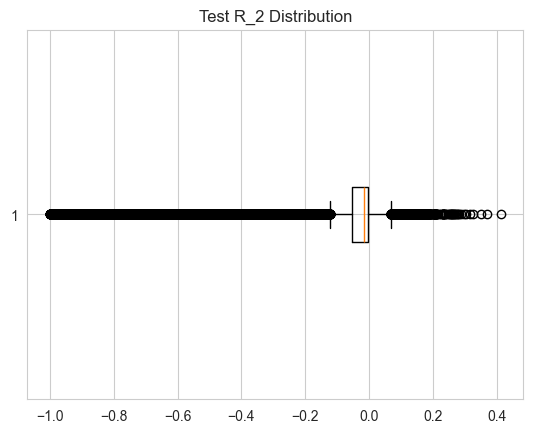

In [62]:
plt.boxplot(list(results_df['test_R_2']), orientation = "horizontal")
plt.title("Test R_2 Distribution")

# Display the plot
plt.show() #looks a bit questionable

## 2. Temporal Dynamics Analysis

**Key Question:** Does prediction performance change across the sentence timeline?

Analyzing 395 high-performing electrode-timewindow combinations (R² ≥ 0.1)


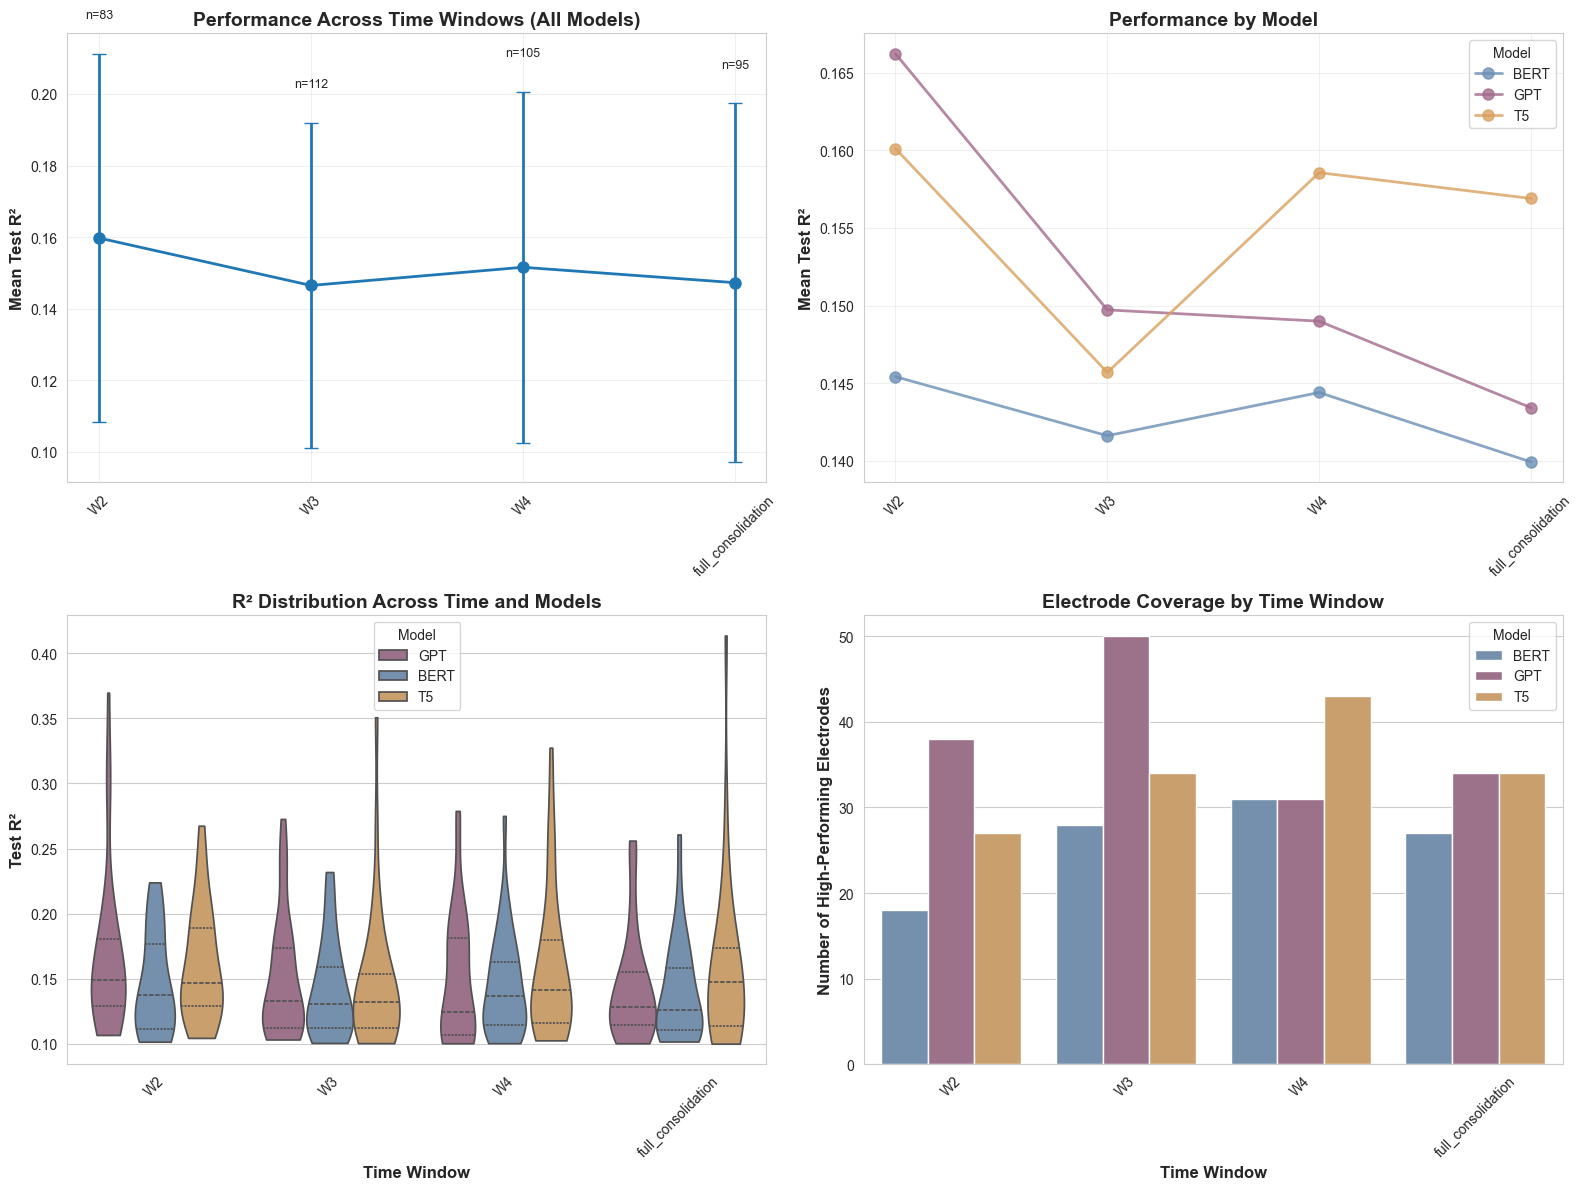


Temporal Dynamics Summary:
       time_window     mean      std  count
                W2 0.159722 0.051508     83
                W3 0.146472 0.045547    112
                W4 0.151556 0.049117    105
full_consolidation 0.147250 0.050117     95


In [63]:
# Filter to significant electrodes
sig_results = results_df[(results_df['test_R_2'] >= R2_THRESHOLD)].copy() #Just star the electrode if its significant instead of hard filtering

print(
    f"Analyzing {len(sig_results)} high-performing electrode-timewindow combinations "
    f"(R² ≥ {R2_THRESHOLD})"
)

# Define time window order
time_order = ['W2', 'W3', 'W4', 'full_consolidation']
sig_results['time_window'] = pd.Categorical(
    sig_results['time_window'],
    categories=time_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


ax = axes[0, 0]

time_summary = (
    sig_results
    .groupby('time_window')['test_R_2']
    .agg(['mean', 'std', 'count'])
    .reindex(time_order)
    .reset_index()
)

ax.errorbar(
    range(len(time_summary)),
    time_summary['mean'],
    yerr=time_summary['std'],
    marker='o',
    linewidth=2,
    markersize=8,
    capsize=5
)

ax.set_xticks(range(len(time_summary)))
ax.set_xticklabels(time_summary['time_window'], rotation=45)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_title('Performance Across Time Windows (All Models)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add counts
for i, row in time_summary.iterrows():
    ax.text(
        i,
        row['mean'] + row['std'] + 0.01,
        f"n={int(row['count'])}",
        ha='center',
        fontsize=9
    )


ax = axes[0, 1]

for model in MODELS:
    model_data = (
        sig_results[sig_results['model'] == model]
        .groupby('time_window')['test_R_2']
        .mean()
        .reindex(time_order)
    )

    ax.plot(
        range(len(time_order)),
        model_data.values,
        marker='o',
        linewidth=2,
        markersize=8,
        label=model,
        alpha=0.8,
        color=MODEL_COLORS[model]
    )

ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order, rotation=45)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_title('Performance by Model', fontsize=14, fontweight='bold')
ax.legend(title='Model')
ax.grid(True, alpha=0.3)

ax = axes[1, 0]

sns.violinplot(
    data=sig_results,
    x='time_window',
    y='test_R_2',
    hue='model',
    palette=MODEL_COLORS,
    cut=0,
    inner='quartile',
    ax=ax
)

ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax.set_title('R² Distribution Across Time and Models', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Model')


ax = axes[1, 1]

count_data = (
    sig_results
    .groupby(['time_window', 'model'])
    .size()
    .reset_index(name='count')
)

sns.barplot(
    data=count_data,
    x='time_window',
    y='count',
    hue='model',
    palette=MODEL_COLORS,
    ax=ax
)

ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of High-Performing Electrodes', fontsize=12, fontweight='bold')
ax.set_title('Electrode Coverage by Time Window', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Model')


plt.tight_layout()
plt.savefig(
    'figures/time_windows/temporal_dynamics_overview.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("\nTemporal Dynamics Summary:")
print(time_summary.to_string(index=False))


## 4. Consolidation vs. Active Processing

**Question:** Does consolidation show different encoding patterns than word presentation?

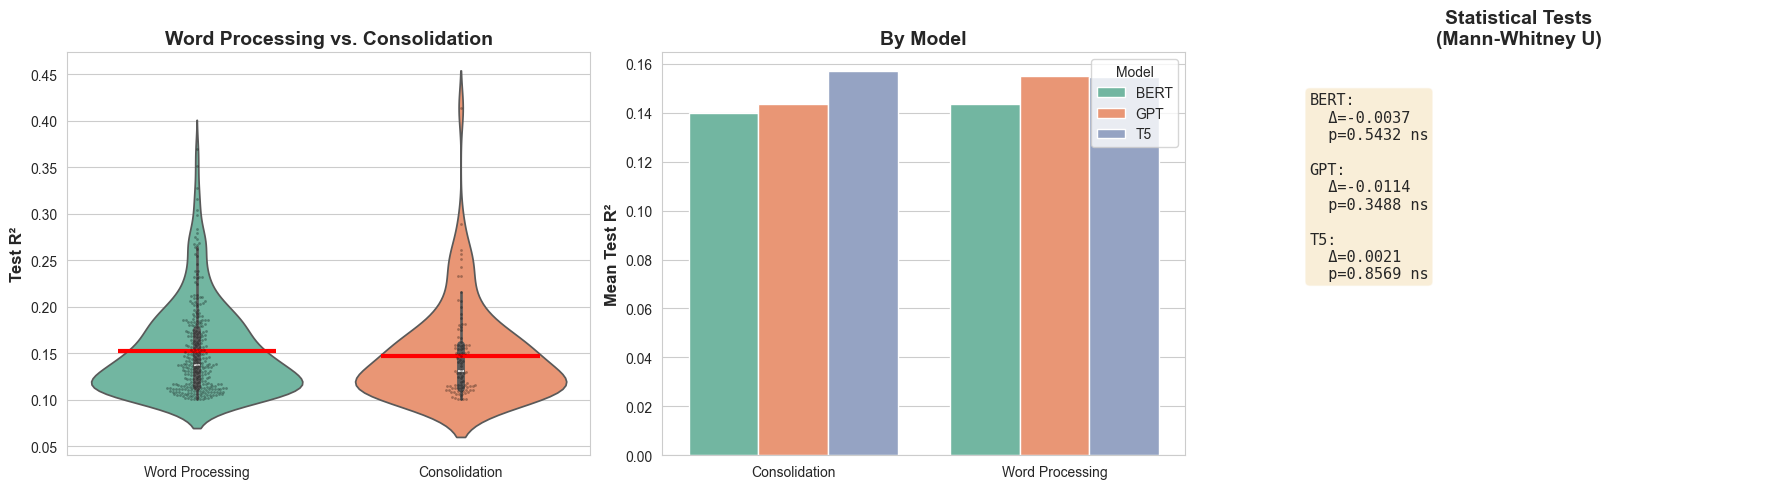


Consolidation vs. Word Processing:
                 count      mean       std       min       25%       50%  \
period                                                                     
Consolidation     95.0  0.147250  0.050117  0.100159  0.112608  0.130557   
Word Processing  300.0  0.151917  0.048630  0.100471  0.114029  0.137599   

                      75%       max  
period                               
Consolidation    0.159094  0.413675  
Word Processing  0.174356  0.369778  


In [64]:
# Compare word processing vs consolidation
word_data_all = sig_results[sig_results['time_window'].isin([ 'W2', 'W3', 'W4'])].copy()
word_data_all['period'] = 'Word Processing'

consol_data = sig_results[sig_results['time_window'] == 'full_consolidation'].copy()
consol_data['period'] = 'Consolidation'

comparison_data = pd.concat([word_data_all, consol_data])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution comparison
ax = axes[0]
sns.violinplot(data=comparison_data, x='period', y='test_R_2', ax=ax, palette='Set2')
sns.swarmplot(data=comparison_data, x='period', y='test_R_2', ax=ax, color='black', alpha=0.3, size=2)
ax.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Word Processing vs. Consolidation', fontsize=14, fontweight='bold')

# Add means
means = comparison_data.groupby('period')['test_R_2'].mean()
for i, period in enumerate(['Word Processing', 'Consolidation']):
    ax.hlines(means[period], i-0.3, i+0.3, colors='red', linestyles='solid', linewidth=3)

# Plot 2: By model
ax = axes[1]
model_comparison = comparison_data.groupby(['period', 'model'])['test_R_2'].mean().reset_index()
sns.barplot(data=model_comparison, x='period', y='test_R_2', hue='model', ax=ax, palette='Set2')
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_title('By Model', fontsize=14, fontweight='bold')
ax.legend(title='Model')

# Plot 3: Statistical comparison
ax = axes[2]
from scipy.stats import mannwhitneyu

results_text = []
for model in MODELS:
    word_vals = word_data_all[word_data_all['model'] == model]['test_R_2'].values
    consol_vals = consol_data[consol_data['model'] == model]['test_R_2'].values
    
    if len(word_vals) > 0 and len(consol_vals) > 0:
        stat, p = mannwhitneyu(word_vals, consol_vals, alternative='two-sided')
        mean_diff = np.mean(consol_vals) - np.mean(word_vals)
        
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        results_text.append(f"{model}:\n  Δ={mean_diff:.4f}\n  p={p:.4f} {sig}")

ax.text(0.1, 0.9, '\n\n'.join(results_text), transform=ax.transAxes, 
        fontsize=11, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_title('Statistical Tests\n(Mann-Whitney U)', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('figures/time_windows/consolidation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConsolidation vs. Word Processing:")
print(comparison_data.groupby('period')['test_R_2'].describe())

## 5. Brain Region Analysis by Time Window

**Question:** Do different brain regions show time-specific encoding?

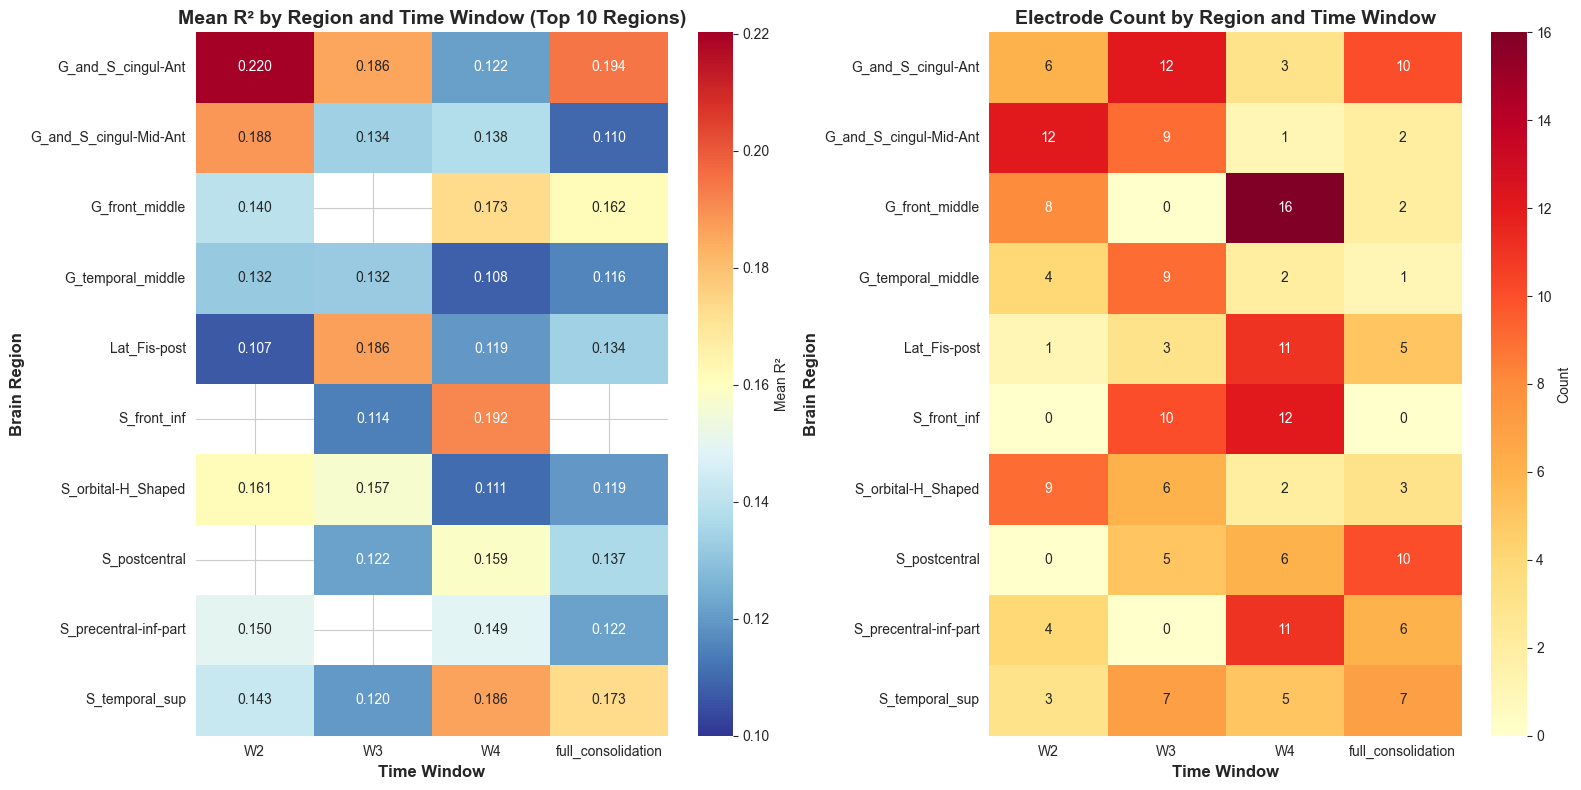


Top 5 Regions by Time Window:

W2:
              parcLabel     mean  count
     G_and_S_cingul-Ant 0.220271      6
 G_and_S_cingul-Mid-Ant 0.188410     12
G_Ins_lg_and_S_cent_ins 0.179443      1
            S_front_sup 0.176631     10
            Hippocampus 0.168629      3

W3:
              parcLabel     mean  count
               G_rectus 0.238310      1
            G_front_sup 0.228657      2
   G_front_inf-Triangul 0.205699      4
G_Ins_lg_and_S_cent_ins 0.190963      5
           Lat_Fis-post 0.186448      3

W4:
            parcLabel     mean  count
             G_rectus 0.195544      5
          S_front_inf 0.191516     12
       S_temporal_sup 0.186292      5
       G_front_middle 0.173100     16
S_circular_insula_sup 0.163238      1

full_consolidation:
              parcLabel     mean  count
S_oc_middle_and_Lunatus 0.200114      1
     G_and_S_cingul-Ant 0.194498     10
  S_precentral-sup-part 0.177749      4
         S_temporal_sup 0.172941      7
        S_occipital_ant 0

In [65]:
# Top regions by time window
if 'parcLabel' in sig_results.columns:
    region_time = sig_results.groupby(['parcLabel', 'time_window'])['test_R_2'].agg(['mean', 'count']).reset_index()
    
    # Get top 10 regions overall
    top_regions = region_time.groupby('parcLabel')['count'].sum().nlargest(10).index
    region_subset = region_time[region_time['parcLabel'].isin(top_regions)]
    
    # Create heatmap
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Performance heatmap
    ax = axes[0]
    pivot_perf = region_subset.pivot(index='parcLabel', columns='time_window', values='mean')
    pivot_perf = pivot_perf.reindex(columns=time_order)
    sns.heatmap(pivot_perf, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax, 
                cbar_kws={'label': 'Mean R²'}, vmin=R2_THRESHOLD)
    ax.set_title('Mean R² by Region and Time Window (Top 10 Regions)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
    ax.set_ylabel('Brain Region', fontsize=12, fontweight='bold')
    
    # Count heatmap
    ax = axes[1]
    pivot_count = region_subset.pivot(index='parcLabel', columns='time_window', values='count')
    pivot_count = pivot_count.reindex(columns=time_order)
    sns.heatmap(pivot_count, annot=True, fmt='g', cmap='YlOrRd', ax=ax, 
                cbar_kws={'label': 'Count'})
    ax.set_title('Electrode Count by Region and Time Window', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
    ax.set_ylabel('Brain Region', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/time_windows/brain_regions_by_time.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nTop 5 Regions by Time Window:")
    for tw in time_order:
        tw_data = region_time[region_time['time_window'] == tw].nlargest(5, 'mean')
        print(f"\n{tw}:")
        print(tw_data[['parcLabel', 'mean', 'count']].to_string(index=False))
else:
    print("No brain region information available")

## 6. Individual Electrode Temporal Profiles

**Analysis:** Track individual electrodes across time windows

Top 20 electrodes by temporal coverage:
 subject     electrode model  n_windows  mean_R2
       3  electrode_74   GPT         11 0.137497
       9  electrode_36    T5          9 0.127901
       3  electrode_56   GPT          8 0.158369
       3  electrode_56    T5          8 0.175697
       3  electrode_68   GPT          8 0.175048
       3 electrode_119   GPT          7 0.111986
       3  electrode_15   GPT          7 0.201345
       3  electrode_46   GPT          7 0.208283
       8  electrode_28   GPT          7 0.140045
       3 electrode_118    T5          6 0.131567
       3  electrode_98  BERT          6 0.175211
       3  electrode_98    T5          6 0.168640
       3 electrode_169    T5          5 0.237662
       3  electrode_20  BERT          5 0.112931
       3  electrode_44    T5          5 0.219847
       1  electrode_66   GPT          4 0.117097
       1  electrode_83   GPT          4 0.112750
       3 electrode_100   GPT          4 0.115196
       3 electrode_106   GPT 

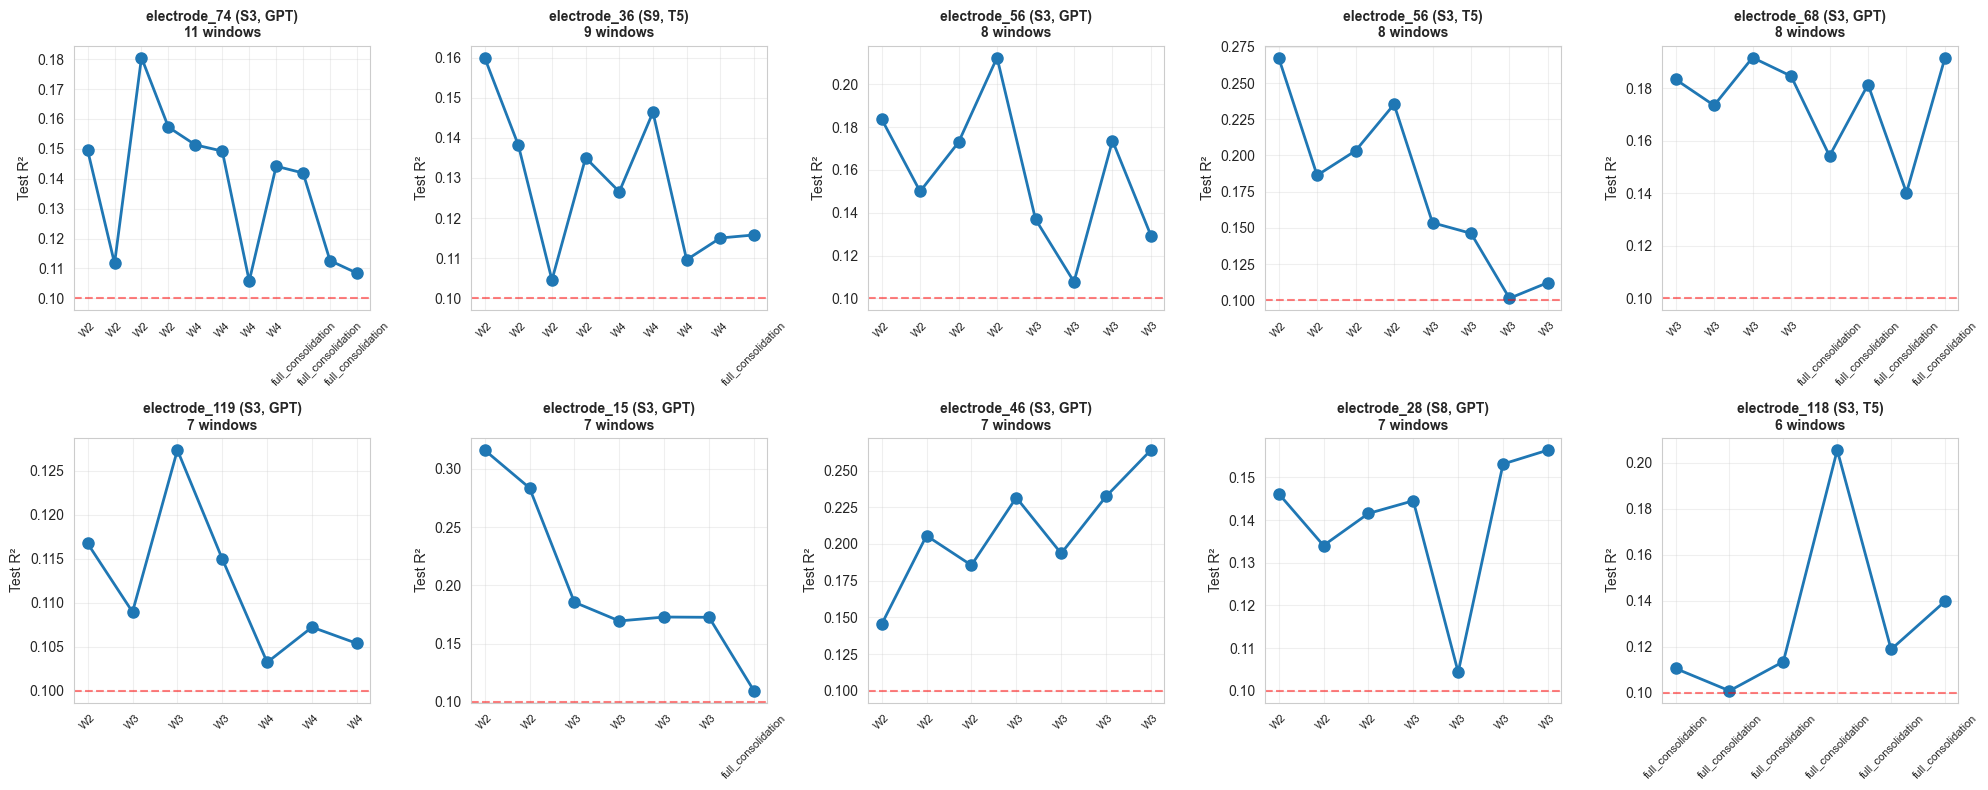

In [66]:
# Find electrodes that are significant across multiple time windows
electrode_coverage = sig_results.groupby(['subject', 'electrode', 'model']).agg({
    'time_window': 'count',
    'test_R_2': 'mean'
}).reset_index()
electrode_coverage.columns = ['subject', 'electrode', 'model', 'n_windows', 'mean_R2']

# Find top "persistent" electrodes (significant in many windows)
top_persistent = electrode_coverage.nlargest(20, 'n_windows')

print(f"Top 20 electrodes by temporal coverage:")
print(top_persistent.to_string(index=False))

# Visualize temporal profiles of top 10
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (idx, row) in enumerate(top_persistent.head(10).iterrows()):
    ax = axes[i]
    
    # Get this electrode's data across time
    elec_data = sig_results[
        (sig_results['subject'] == row['subject']) & 
        (sig_results['electrode'] == row['electrode']) & 
        (sig_results['model'] == row['model'])
    ].copy()
    
    # Sort by time window
    elec_data = elec_data.sort_values('time_window')
    
    ax.plot(range(len(elec_data)), elec_data['test_R_2'].values, 
            marker='o', linewidth=2, markersize=8)
    ax.set_xticks(range(len(elec_data)))
    ax.set_xticklabels(elec_data['time_window'].values, rotation=45, fontsize=8)
    ax.set_ylabel('Test R²', fontsize=10)
    ax.set_title(f"{row['electrode']} (S{row['subject']}, {row['model']})\n{row['n_windows']} windows", 
                fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=R2_THRESHOLD, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/time_windows/persistent_electrodes.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
# Create top electrodes ranking based on mean test R² performance
top_electrodes = (
    results_df
    .groupby('electrode_id')
    .agg({
        'test_R_2': 'mean',
        'test_R': 'mean',
        'subject': 'first',
        'parcLabel': 'first',
        'hemisphere': 'first'
    })
    .reset_index()
    .sort_values('test_R_2', ascending=False)
    .reset_index(drop=True)
)

top_electrodes.columns = ['electrode_id', 'mean_test_R2', 'mean_test_R', 'subject', 'parcLabel', 'hemisphere']

print("\nTop 10 Electrodes by Mean Test R²:")
print(top_electrodes.head(10).to_string(index=False))

def plot_individual_electrode_profiles(df, top_electrodes_df, n_electrodes=5, save_path=None):
    """
    Create detailed profile for each of the top N electrodes using parcLabel.
    Shows both R² (bars) and Pearson R (line) on dual axes.
    Column 4 shows actual vs predicted values.
    """
    top_elec_ids = top_electrodes_df['electrode_id'].values[:n_electrodes]
    
    # Increased figure size for better spacing
    fig, axes = plt.subplots(n_electrodes, 4, figsize=(24, 5*n_electrodes))
    if n_electrodes == 1:
        axes = axes.reshape(1, -1)
    
    # Create figure-level legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    
    legend_elements = [
        Patch(facecolor='steelblue', edgecolor='black', alpha=0.7, label='R² (bars, left axis)'),
        Line2D([0], [0], color='black', marker='o', linewidth=2.5, markersize=8, label='Pearson R (line, right axis)')
    ]
    
    for row, elec_id in enumerate(top_elec_ids):
        elec_data = df[df['electrode_id'] == elec_id]
        subject = elec_data['subject'].iloc[0]
        region = elec_data['parcLabel'].iloc[0] if 'parcLabel' in elec_data.columns and pd.notna(elec_data['parcLabel'].iloc[0]) else 'Unknown'
        
        # Column 1: Performance by model
        ax = axes[row, 0]
        model_r2 = elec_data.groupby('model')['test_R_2'].mean().reindex(MODELS)
        model_r = elec_data.groupby('model')['test_R'].mean().reindex(MODELS)
        
        x = np.arange(len(MODELS))
        
        # R² bars on left axis
        color1 = 'steelblue'
        ax.bar(x, model_r2.values, alpha=0.7, color=color1,
               edgecolor='black', linewidth=1.5)
        ax.set_ylabel('R²', fontweight='bold', fontsize=11, color=color1)
        ax.tick_params(axis='y', labelcolor=color1, labelsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS, fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Pearson R line on right axis
        ax2 = ax.twinx()
        color2 = 'black'
        ax2.plot(x, model_r.values, color=color2, marker='o',
                linewidth=2.5, markersize=8)
        ax2.set_ylabel('Pearson R', fontweight='bold', fontsize=11, color=color2)
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)
        
        ax.set_title(f'Rank {row+1}: {elec_id}\nSubj {subject}, {region}', 
                    fontweight='bold', fontsize=12, pad=15)
        
        # Add panel label
        panel_labels = ['A', 'B', 'C', 'D']
        if row == 0:
            ax.text(-0.15, 1.15, panel_labels[0], transform=ax.transAxes,
                   fontsize=16, fontweight='bold', va='top')
        
        # Column 2: Performance by condition
        ax = axes[row, 1]
        cond_r2 = elec_data[elec_data['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
            'condition')['test_R_2'].mean().reindex(SEMANTIC_CONDITIONS)
        cond_r = elec_data[elec_data['condition'].isin(SEMANTIC_CONDITIONS)].groupby(
            'condition')['test_R'].mean().reindex(SEMANTIC_CONDITIONS)
        
        x = np.arange(len(SEMANTIC_CONDITIONS))
        
        # R² bars on left axis
        color1 = 'steelblue'
        ax.bar(x, cond_r2.values, alpha=0.7, color=color1,
              edgecolor='black', linewidth=1.5)
        ax.set_ylabel('R²', fontweight='bold', fontsize=11, color=color1)
        ax.tick_params(axis='y', labelcolor=color1, labelsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(SEMANTIC_CONDITIONS, fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Pearson R line on right axis
        ax2 = ax.twinx()
        color2 = 'black'
        ax2.plot(x, cond_r.values, color=color2, marker='o',
                linewidth=2.5, markersize=8)
        ax2.set_ylabel('Pearson R', fontweight='bold', fontsize=11, color=color2)
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)
        
        ax.set_title('By Condition', fontweight='bold', fontsize=12, pad=15)
        
        # Add panel label
        if row == 0:
            ax.text(-0.15, 1.15, panel_labels[1], transform=ax.transAxes,
                   fontsize=16, fontweight='bold', va='top')
        
        # Column 3: Performance by time window
        ax = axes[row, 2]
        time_r2 = elec_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        time_r = elec_data.groupby('time_window')['test_R'].mean().reindex(TIME_WINDOWS)
        
        x = np.arange(len(TIME_WINDOWS))
        
        # R² bars on left axis
        color1 = 'steelblue'
        ax.bar(x, time_r2.values, alpha=0.7, color=color1,
              edgecolor='black', linewidth=1.5)
        ax.set_ylabel('R²', fontweight='bold', fontsize=11, color=color1)
        ax.tick_params(axis='y', labelcolor=color1, labelsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([tw.replace('_', '\n') for tw in TIME_WINDOWS], 
                          rotation=0, fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Pearson R line on right axis
        ax2 = ax.twinx()
        color2 = 'black'
        ax2.plot(x, time_r.values, color=color2, marker='o',
                linewidth=2.5, markersize=8)
        ax2.set_ylabel('Pearson R', fontweight='bold', fontsize=11, color=color2)
        ax2.tick_params(axis='y', labelcolor=color2, labelsize=10)
        
        ax.set_title('Temporal Profile', fontweight='bold', fontsize=12, pad=15)
        
        # Add panel label
        if row == 0:
            ax.text(-0.15, 1.15, panel_labels[2], transform=ax.transAxes,
                   fontsize=16, fontweight='bold', va='top')
        
        # Column 4: Actual vs Predicted (using best performing model/condition/time)
        ax = axes[row, 3]
        
        # Find the best performing configuration for this electrode
        best_config = elec_data.nlargest(1, 'test_R_2').iloc[0]
        best_subject = best_config['subject']
        best_condition = best_config['condition']
        best_model = best_config['model']
        best_layer = best_config['layer']
        best_time = best_config['time_window']
        electrode_num = best_config['electrode']
        test_r2 = best_config['test_R_2']
        test_r = best_config['test_R']
        
        # Load the results object to get predictions
        try:
            results = load_results(best_subject, best_condition, best_layer, best_time)
            model_key = f"{best_model}_df"
            
            if model_key in results and results[model_key] is not None:
                # Get the actual test data and predictions
                y_test = results[model_key]['y_test']
                model_obj = results[model_key]['model']
                X_test = results[model_key]['X_test_scaled']
                
                # Get predictions for this specific electrode
                y_pred = model_obj.predict(X_test)
                
                # Extract the specific electrode's data
                elec_idx = int(electrode_num) if isinstance(electrode_num, str) and electrode_num.isdigit() else electrode_num
                
                if elec_idx < y_test.shape[1] and elec_idx < y_pred.shape[1]:
                    actual = y_test[:, elec_idx]
                    predicted = y_pred[:, elec_idx]
                    
                    # Plot actual vs predicted
                    ax.scatter(actual, predicted, s=60, alpha=0.6,
                              edgecolors='black', linewidths=1, c='#3498db')
                    
                    # Add identity line
                    min_val = min(actual.min(), predicted.min())
                    max_val = max(actual.max(), predicted.max())
                    ax.plot([min_val, max_val], [min_val, max_val], 
                           'r--', linewidth=2, alpha=0.7, label='Perfect prediction')
                    
                    ax.set_xlabel('Actual Neural Activity', fontweight='bold', fontsize=11)
                    ax.set_ylabel('Predicted Neural Activity', fontweight='bold', fontsize=11)
                    ax.set_title(f'Best Config: {best_model}, {best_condition}, {best_time}\nR²={test_r2:.3f}, r={test_r:.3f}', 
                                fontweight='bold', fontsize=11, pad=15)
                    ax.grid(True, alpha=0.3)
                    ax.tick_params(axis='both', labelsize=10)
                    ax.legend(fontsize=9, loc='upper left')
                else:
                    ax.text(0.5, 0.5, f'Electrode index\nout of range\n({elec_idx})', 
                           transform=ax.transAxes, ha='center', va='center',
                           fontsize=11, color='red')
            else:
                ax.text(0.5, 0.5, f'Model data\nnot available\n({best_model})', 
                       transform=ax.transAxes, ha='center', va='center',
                       fontsize=11, color='orange')
        except Exception as e:
            # Fallback: show train vs test R² if we can't load predictions
            ax.text(0.5, 0.5, f'Could not load\npredictions\n{str(e)[:30]}...', 
                   transform=ax.transAxes, ha='center', va='center',
                   fontsize=10, color='gray')
        
        # Add panel label
        if row == 0:
            ax.text(-0.15, 1.15, panel_labels[3], transform=ax.transAxes,
                   fontsize=16, fontweight='bold', va='top')
    
    # Add figure-level legend
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.99),
              ncol=2, fontsize=13, frameon=True, fancybox=True, shadow=True,
              framealpha=0.95, edgecolor='black')
    
    plt.suptitle(f'Individual Profiles: Top {n_electrodes} Electrodes',
                fontsize=20, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.985])  # Make room for legend
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig

# Generate individual profiles
fig_profiles = plot_individual_electrode_profiles(results_df, top_electrodes, n_electrodes=5,
                                                 save_path='figures/enhanced_analysis/individual_electrode_profiles.png')

KeyError: 'electrode_id'

## 7. Condition-Specific Temporal Patterns

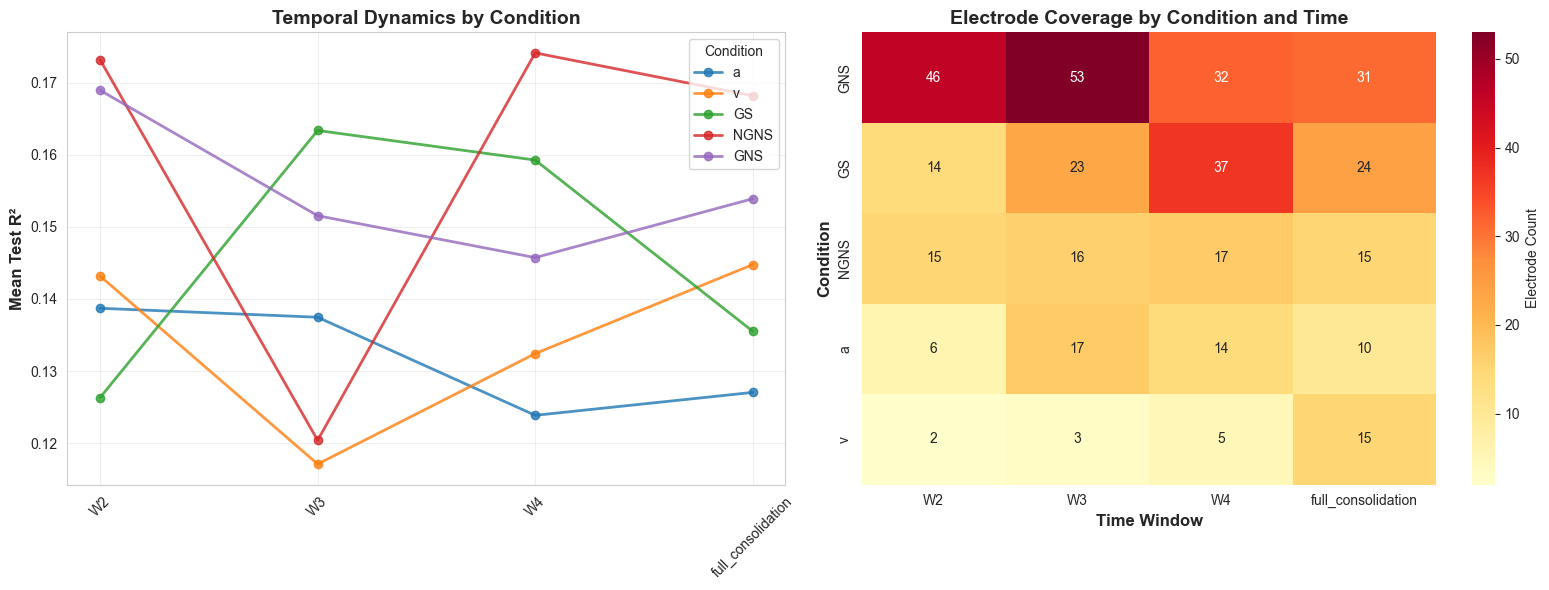

In [ ]:
# Analyze temporal patterns by condition
condition_time = sig_results.groupby(['condition', 'time_window'])['test_R_2'].agg(['mean', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temporal profile by condition
ax = axes[0]
for condition in CONDITIONS:
    cond_data = condition_time[condition_time['condition'] == condition]
    cond_data = cond_data.set_index('time_window').reindex(time_order).reset_index()
    ax.plot(range(len(cond_data)), cond_data['mean'].values, 
            marker='o', linewidth=2, label=condition, alpha=0.8)

ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(time_order, rotation=45)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_title('Temporal Dynamics by Condition', fontsize=14, fontweight='bold')
ax.legend(title='Condition')
ax.grid(True, alpha=0.3)

# Plot 2: Coverage by condition
ax = axes[1]
pivot_cond = condition_time.pivot(index='condition', columns='time_window', values='count')
pivot_cond = pivot_cond.reindex(columns=time_order)
sns.heatmap(pivot_cond, annot=True, fmt='g', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Electrode Count'})
ax.set_title('Electrode Coverage by Condition and Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Time Window', fontsize=12, fontweight='bold')
ax.set_ylabel('Condition', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/time_windows/condition_temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [ ]:
print("="*80)
print("TEMPORAL ANALYSIS SUMMARY")
print("="*80)

print("\n1. Overall Performance by Time Window:")
print("-" * 80)
time_stats = sig_results.groupby('time_window')['test_R_2'].describe()
print(time_stats)

print("\n2. Best Performing Time Window by Model:")
print("-" * 80)
for model in MODELS:
    model_data = sig_results[sig_results['model'] == model]
    best_window = model_data.groupby('time_window')['test_R_2'].mean().idxmax()
    best_score = model_data.groupby('time_window')['test_R_2'].mean().max()
    print(f"{model}: {best_window} (Mean R² = {best_score:.4f})")

print("\n3. Electrode Coverage:")
print("-" * 80)
coverage = sig_results.groupby('time_window').size().sort_index()
print(coverage)

print("\n4. Top 5 Brain Regions by Time Window:")
print("-" * 80)
if 'parcLabel' in sig_results.columns:
    for tw in time_order:
        tw_regions = sig_results[sig_results['time_window'] == tw]['parcLabel'].value_counts().head(5)
        print(f"\n{tw}:")
        for region, count in tw_regions.items():
            print(f"  {region}: {count}")

# Save summary to CSV
summary_df = sig_results.groupby(['time_window', 'model']).agg({
    'test_R_2': ['mean', 'std', 'count'],
    'test_R': 'mean'
}).reset_index()
summary_df.to_csv('figures/time_windows/temporal_summary.csv', index=False)
print("\n✓ Summary statistics saved to figures/time_windows/temporal_summary.csv")

#Highest r^2 happened during consolidation period

TEMPORAL ANALYSIS SUMMARY

1. Overall Performance by Time Window:
--------------------------------------------------------------------------------
                    count      mean       std       min       25%       50%  \
time_window                                                                   
W2                   83.0  0.159722  0.051508  0.101662  0.123179  0.145289   
W3                  112.0  0.146472  0.045547  0.100556  0.112223  0.132915   
W4                  105.0  0.151556  0.049117  0.100471  0.112839  0.136663   
full_consolidation   95.0  0.147250  0.050117  0.100159  0.112608  0.130557   

                         75%       max  
time_window                             
W2                  0.183821  0.369778  
W3                  0.168165  0.350874  
W4                  0.178161  0.327500  
full_consolidation  0.159094  0.413675  

2. Best Performing Time Window by Model:
--------------------------------------------------------------------------------
BERT: W2 

In [ ]:

def plot_top_electrodes_summary(saved_elecs, subject_num, top_n=10, 
                                metric='test_R_2', save_path=None):
    """
    Create a comprehensive visualization of top-performing electrodes.
    Works with your saved_elecs structure.
    """
    if subject_num not in saved_elecs:
        print(f"Subject {subject_num} not found")
        return
    
    # Combine all electrode data
    all_elec_data = pd.concat(saved_elecs[subject_num], ignore_index=True)
    
    # Sort by performance metric
    top_elecs = all_elec_data.nlargest(top_n, metric)
    
    # Create figure
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Bar chart of top electrodes
    ax1 = fig.add_subplot(gs[0, :])
    x_pos = np.arange(len(top_elecs))
    colors_map = {'BERT': '#8dd3c7', 'GPT': '#fb8072', 'T5': '#80b1d3'}
    bar_colors = [colors_map.get(model, 'gray') for model in top_elecs['model']]
    
    bars = ax1.bar(x_pos, top_elecs[metric], color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    
    labels = [f"{row['electrode']}\n{row['model']}\n{row['condition']} {row['parcLabel']}" 
              for _, row in top_elecs.iterrows()]
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax1.set_title(f'Top {top_n} Electrodes - Subject {subject_num}', 
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold (0.1)')
    ax1.legend()
    
    for bar, val in zip(bars, top_elecs[metric]):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Train vs Test R²
    ax2 = fig.add_subplot(gs[1, 0])
    for model in top_elecs['model'].unique():
        model_data = top_elecs[top_elecs['model'] == model]
        ax2.scatter(model_data['train_R_2'], model_data['test_R_2'], 
                   label=model, alpha=0.6, s=100, edgecolors='black', linewidth=1)
    
    max_val = max(top_elecs['train_R_2'].max(), top_elecs['test_R_2'].max())
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1, label='Perfect generalization')
    
    ax2.set_xlabel('Train R²', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Test R²', fontsize=11, fontweight='bold')
    ax2.set_title('Generalization Check', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Model comparison
    ax3 = fig.add_subplot(gs[1, 1])
    model_summary = top_elecs.groupby('model')[metric].agg(['mean', 'std', 'count'])
    x_pos = np.arange(len(model_summary))
    
    bars = ax3.bar(x_pos, model_summary['mean'], 
                   yerr=model_summary['std'], capsize=5,
                   color=[colors_map.get(m, 'gray') for m in model_summary.index],
                   alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(model_summary.index)
    ax3.set_ylabel(f'Mean {metric}', fontsize=11, fontweight='bold')
    ax3.set_title('Model Performance', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    for bar, count in zip(bars, model_summary['count']):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'n={int(count)}', ha='center', va='bottom', fontsize=9)
    
    # Plot 4: Condition breakdown
    ax4 = fig.add_subplot(gs[2, 0])
    condition_summary = top_elecs.groupby(['condition', 'model']).size().unstack(fill_value=0)
    condition_summary.plot(kind='bar', ax=ax4, 
                          color=[colors_map.get(m, 'gray') for m in condition_summary.columns],
                          alpha=0.7, edgecolor='black', linewidth=1.5)
    ax4.set_xlabel('Condition', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax4.set_title('Distribution by Condition', fontsize=12, fontweight='bold')
    ax4.legend(title='Model')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: R² distribution
    ax5 = fig.add_subplot(gs[2, 1])
    for model in top_elecs['model'].unique():
        model_data = top_elecs[top_elecs['model'] == model]
        ax5.hist(model_data[metric], alpha=0.6, label=model, bins=10, 
                edgecolor='black', linewidth=1)
    ax5.set_xlabel('Test R²', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax5.set_title('R² Distribution', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Subject {subject_num} - Top {top_n} Electrode Analysis', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"TOP {top_n} ELECTRODES SUMMARY - SUBJECT {subject_num}")
    print('='*80)
    print(f"\nMean Test R²: {top_elecs[metric].mean():.4f} ± {top_elecs[metric].std():.4f}")
    print(f"Range: {top_elecs[metric].min():.4f} - {top_elecs[metric].max():.4f}")
    print(f"\nModel Distribution:")
    print(top_elecs['model'].value_counts())
    print(f"\nCondition Distribution:")
    print(top_elecs['condition'].value_counts())
    
    return top_elecs


## 9. Export Results for Further Analysis

In [ ]:
# Save significant results with electrode metadata
sig_results.to_csv('figures/time_windows/significant_electrodes_all_windows.csv', index=False)

# Save electrode persistence data
electrode_coverage.to_csv('figures/time_windows/electrode_temporal_coverage.csv', index=False)

print("Results exported:")
print("  - figures/time_windows/significant_electrodes_all_windows.csv")
print("  - figures/time_windows/electrode_temporal_coverage.csv")
print("  - figures/time_windows/temporal_summary.csv")

Results exported:
  - figures/time_windows/significant_electrodes_all_windows.csv
  - figures/time_windows/electrode_temporal_coverage.csv
  - figures/time_windows/temporal_summary.csv


Configuration loaded successfully
Loaded electrode data: 1563 electrodes

Loading Subject 1...

Loading Subject 2...

Loading Subject 3...

Loading Subject 4...

Loading Subject 5...

Loading Subject 6...

Loading Subject 8...

Loading Subject 9...

Loading Subject 10...

Loading Subject 11...

Loading Subject 12...

Loading Subject 13...

Loading Subject 14...

Loading Subject 15...

Loading Subject 16...

Loading Subject 17...

Total dataset: 93744 electrode-model-layer-condition combinations

High-performing electrodes (R² ≥ 0.1): 95

LAYER × CONDITION ANALYSIS


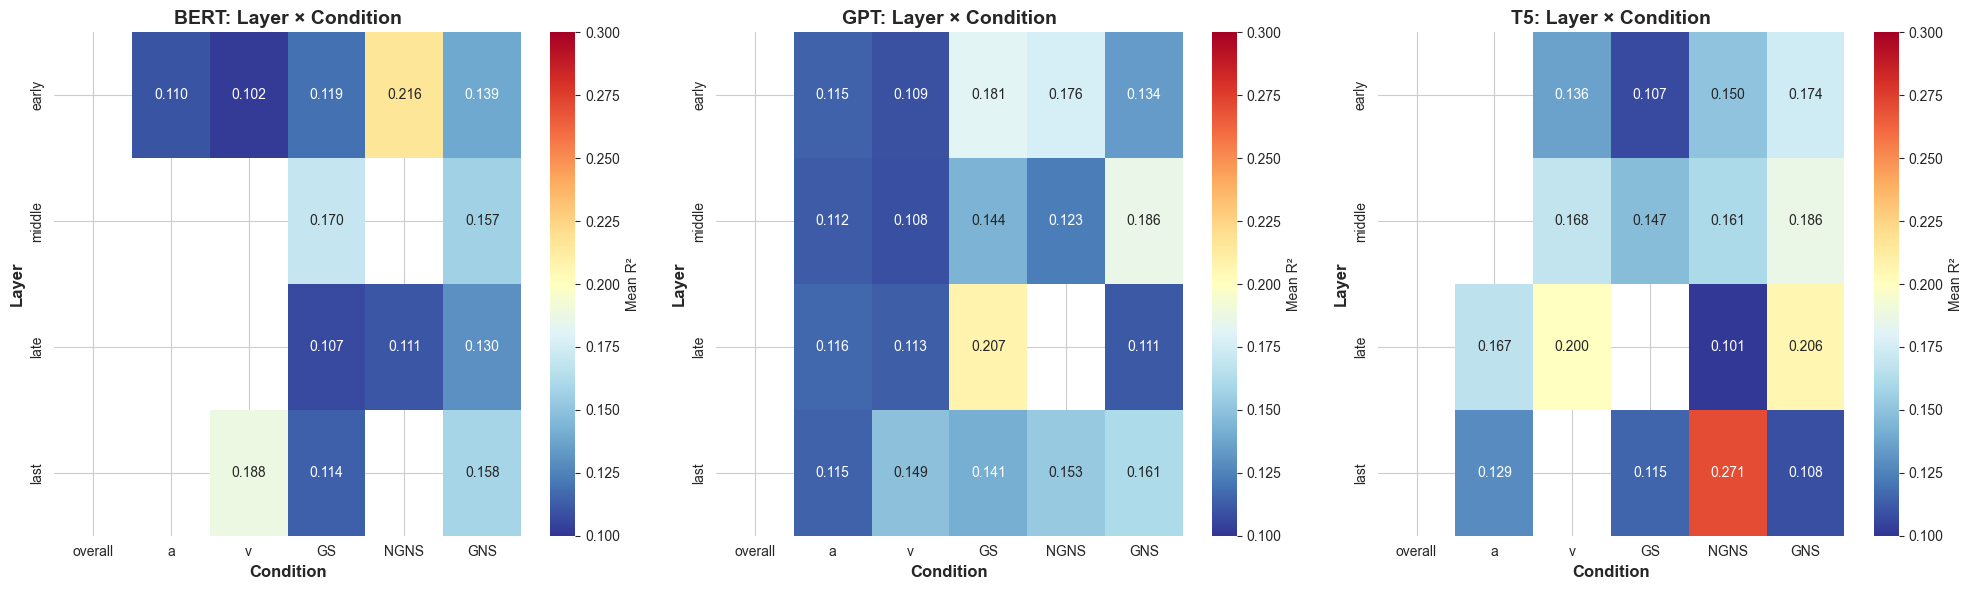


Layer × Condition Summary (All Models):
                      mean  count
layer  condition                 
early  GNS        0.153347      9
       GS         0.123427      6
       NGNS       0.179150      5
       a          0.112105      2
       v          0.121624      6
middle GNS        0.171455     10
       GS         0.154690      8
       NGNS       0.141950      4
       a          0.111798      2
       v          0.148392      3
late   GNS        0.136368      6
       GS         0.140099      3
       NGNS       0.105859      2
       a          0.150087      3
       v          0.170577      3
last   GNS        0.143082      6
       GS         0.121991      7
       NGNS       0.211912      4
       a          0.124123      3
       v          0.161684      3


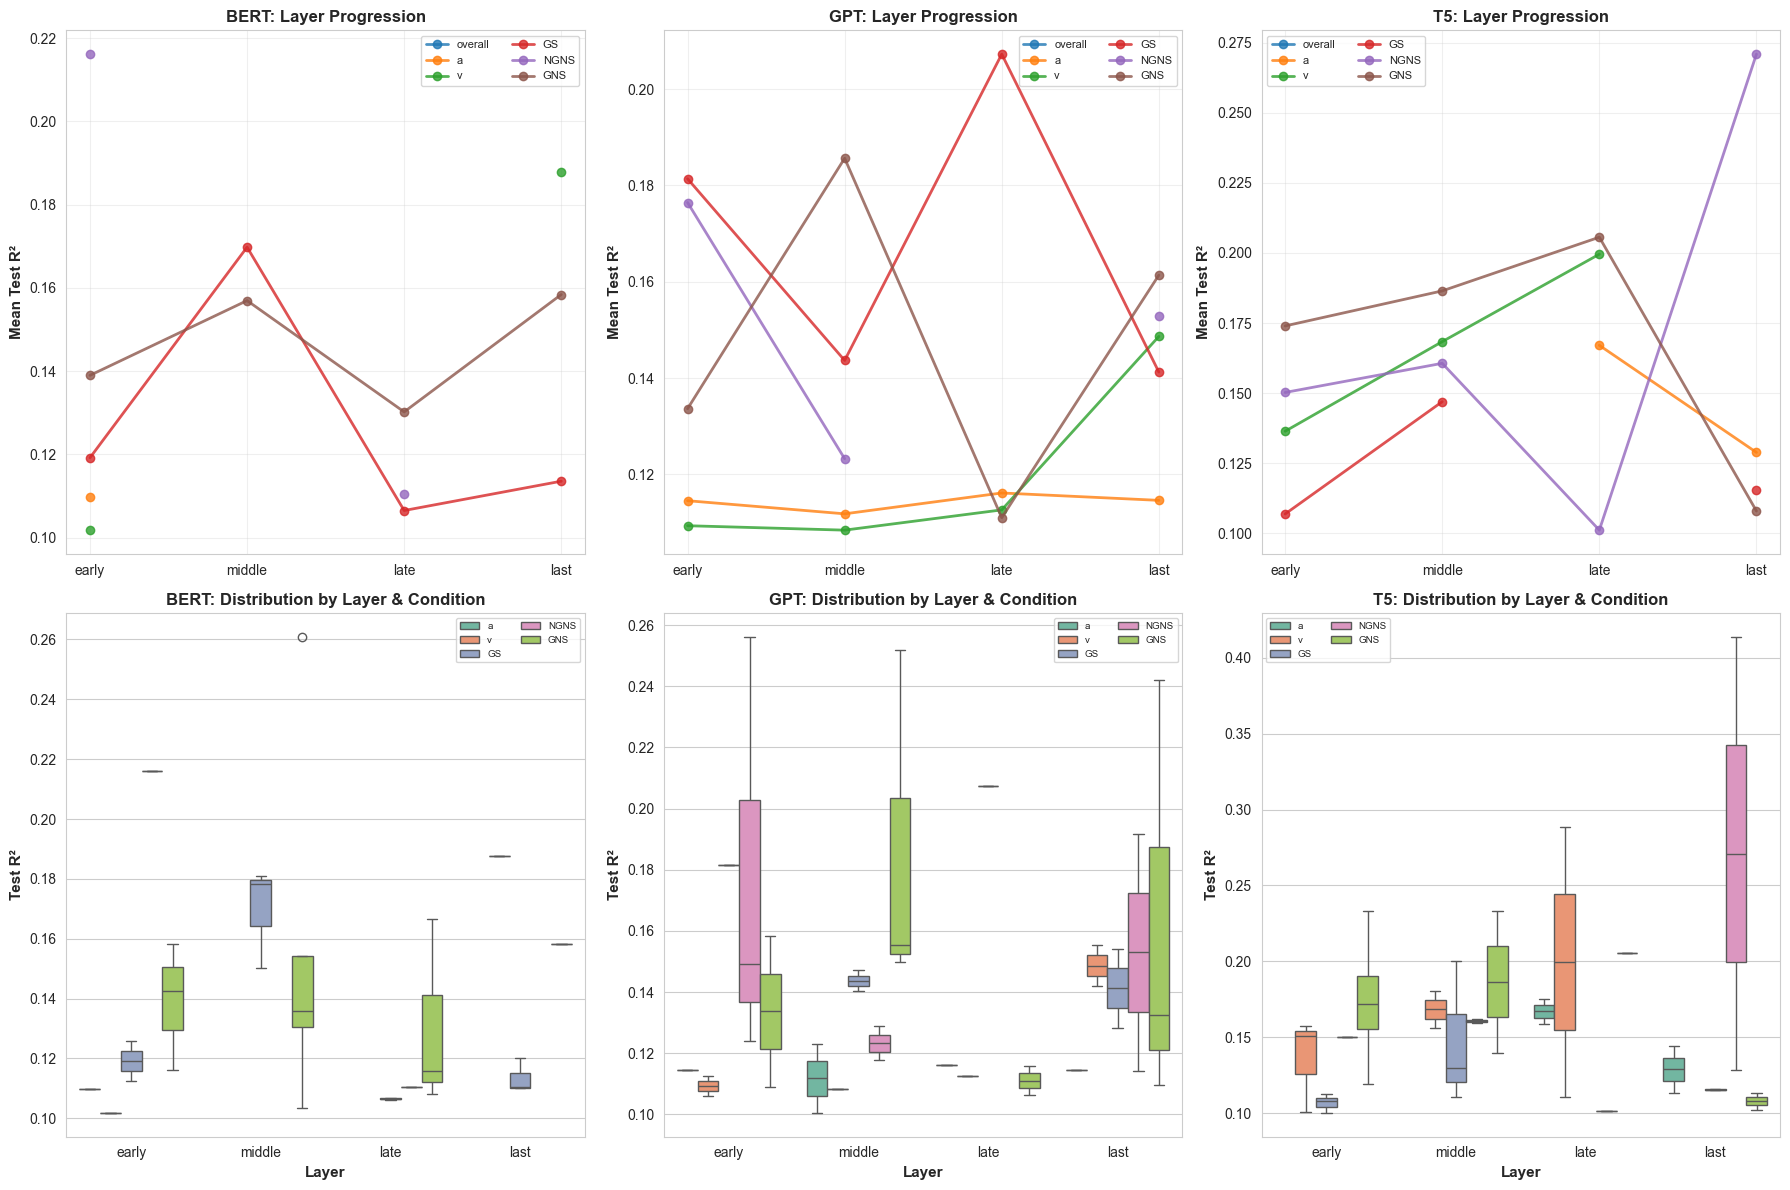


PARTICIPANT-LEVEL ANALYSIS


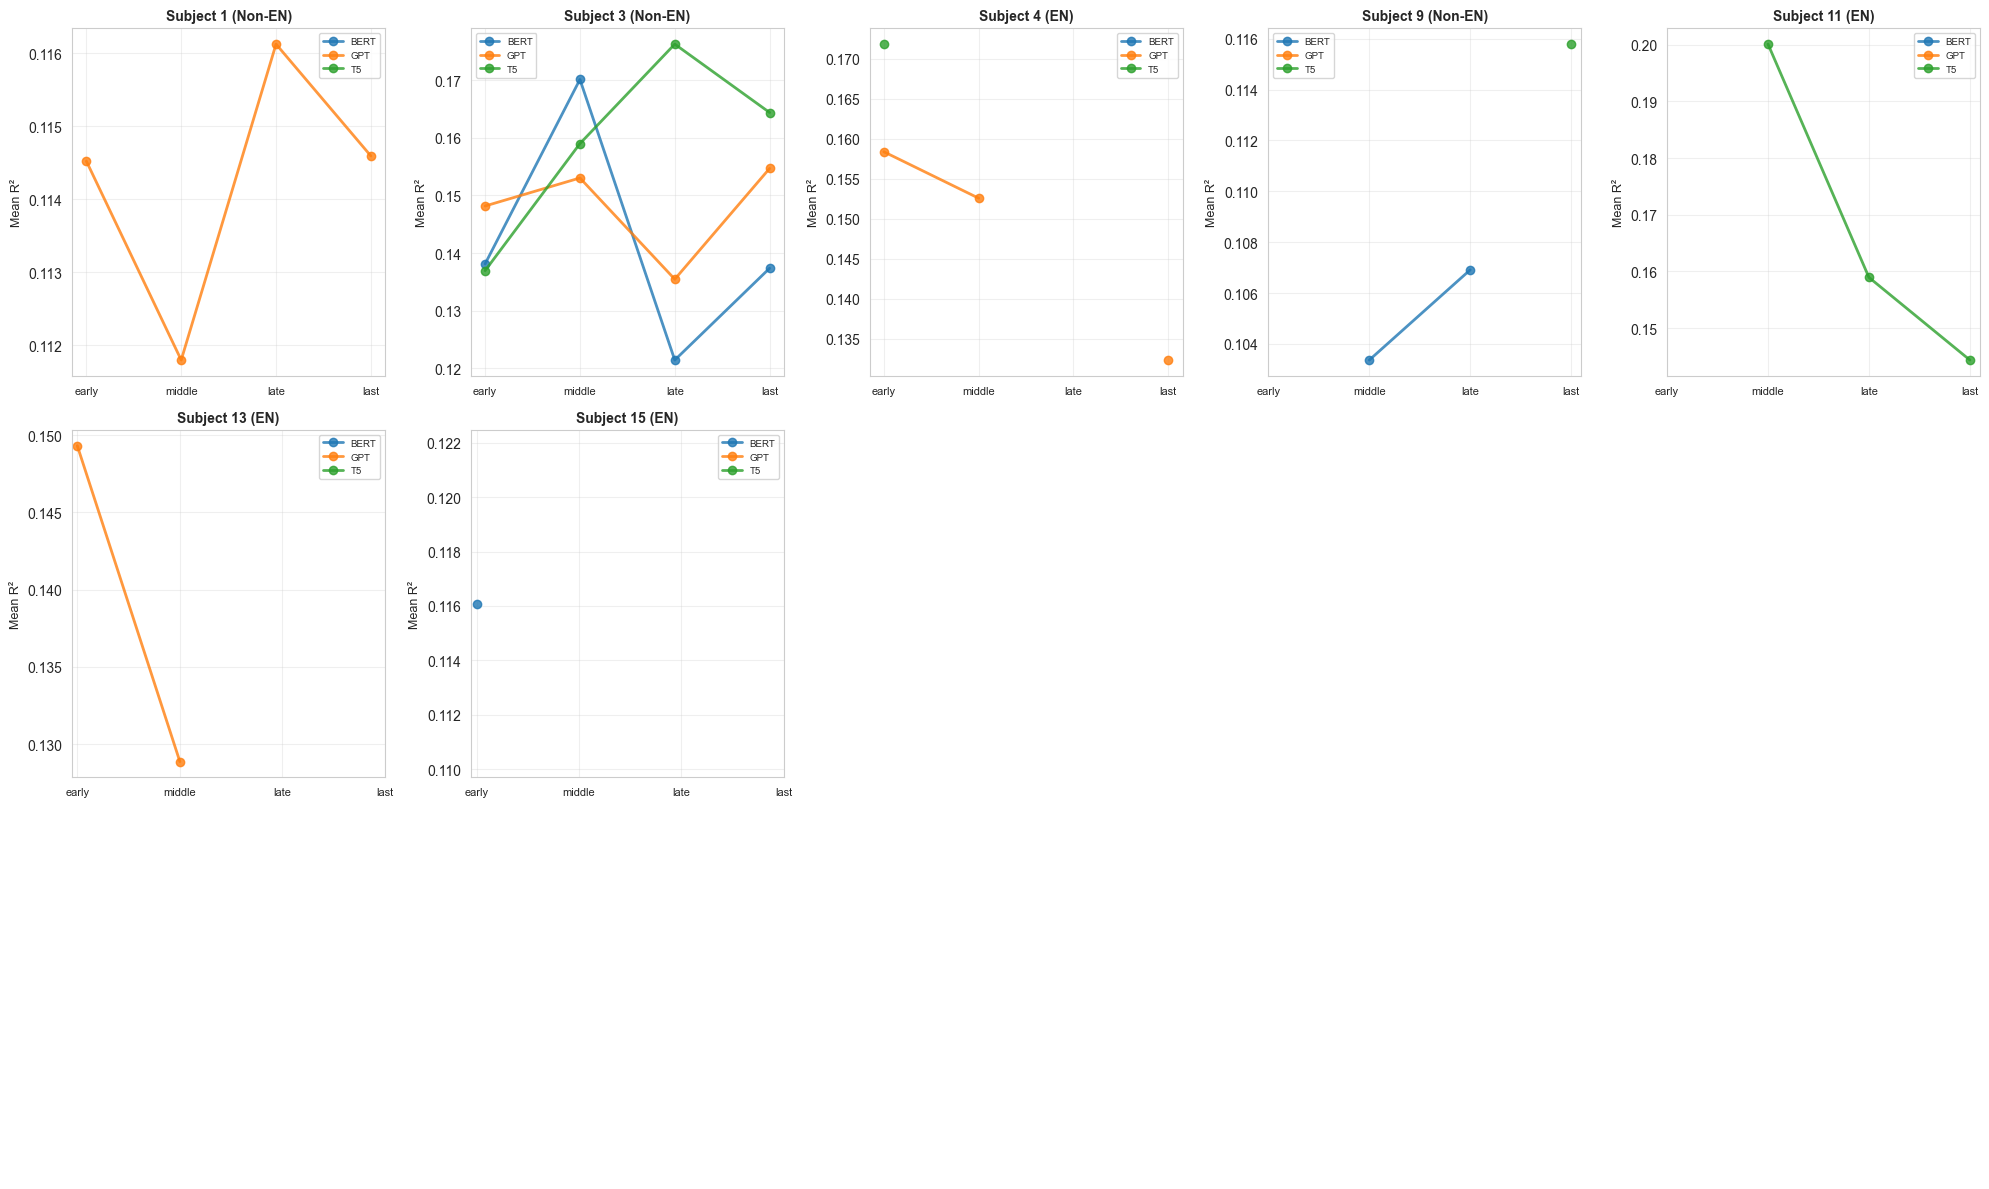

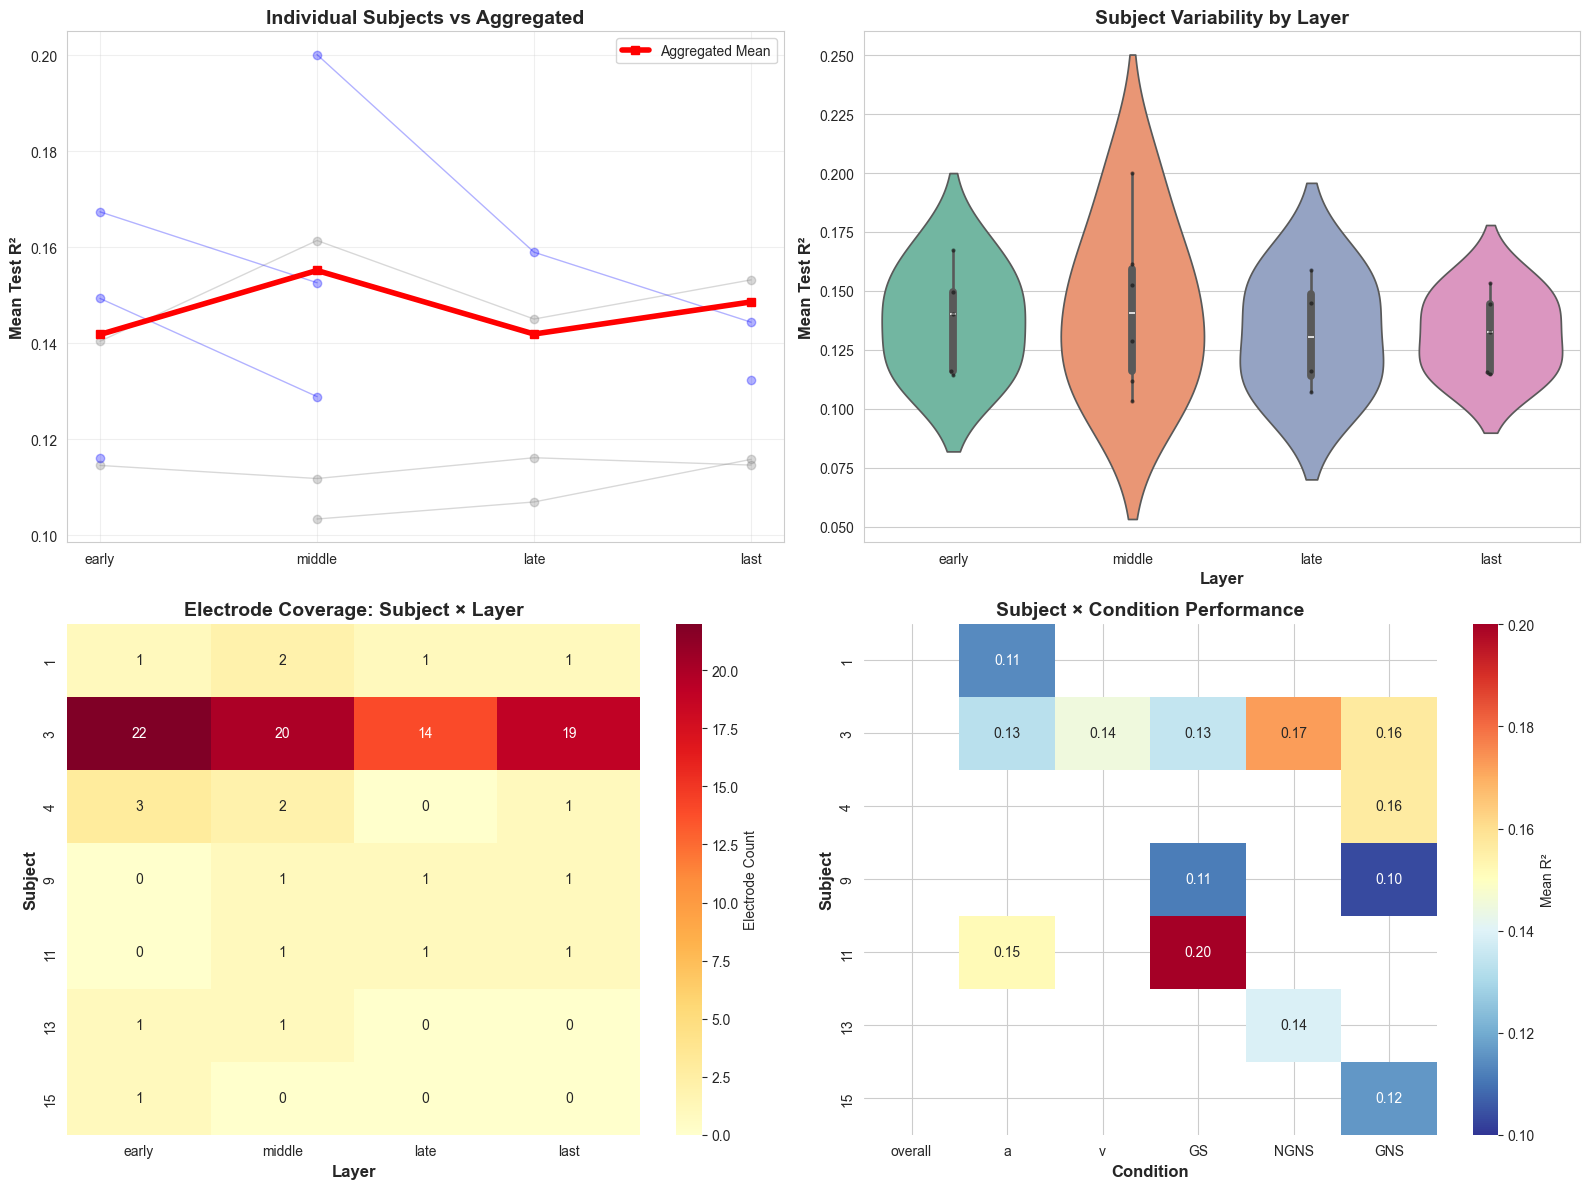


ENGLISH VS NON-ENGLISH SUBJECT COMPARISON

Language Group Summary:
                count      mean       std       min       25%       50%  \
language_group                                                            
English          12.0  0.153106  0.022371  0.116085  0.141358  0.152583   
Non-English      83.0  0.146403  0.052975  0.100159  0.110701  0.125773   

                     75%       max  
language_group                      
English         0.161101  0.200114  
Non-English     0.158822  0.413675  


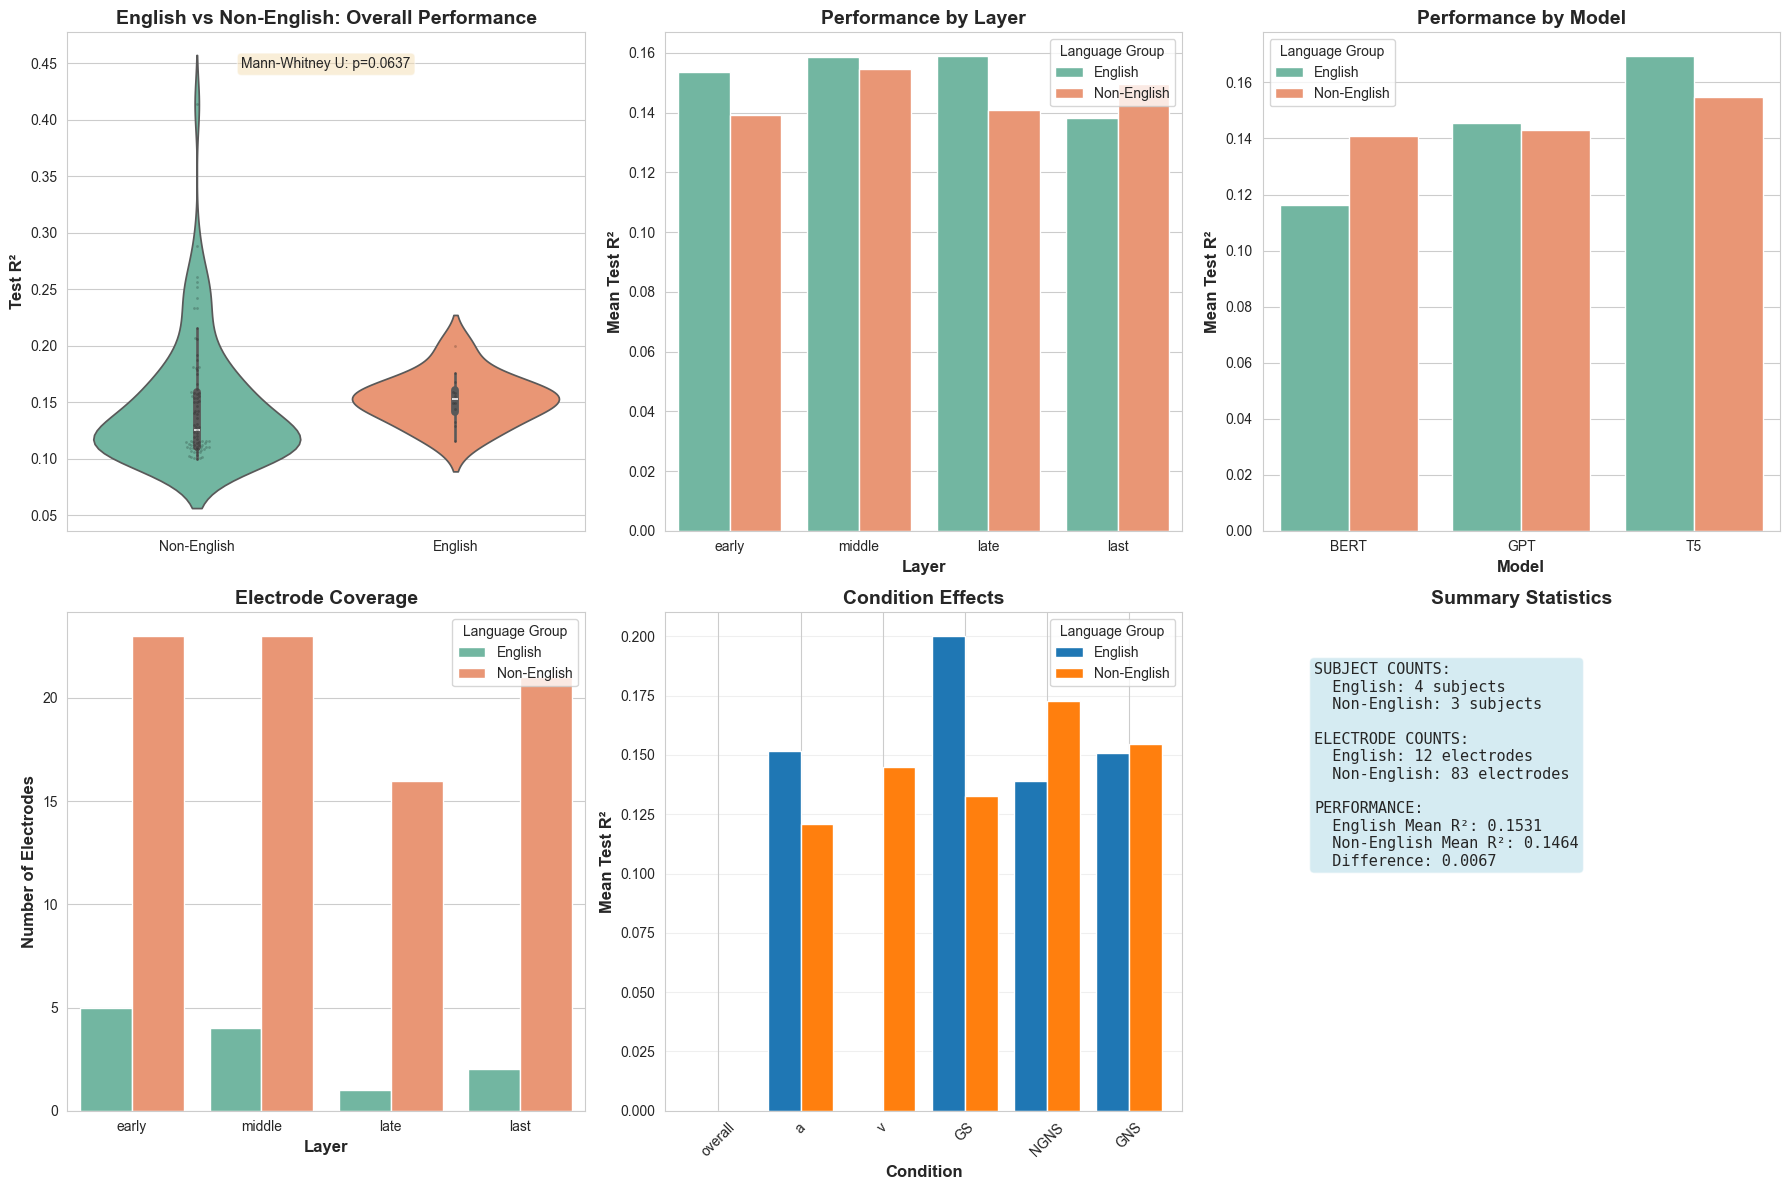

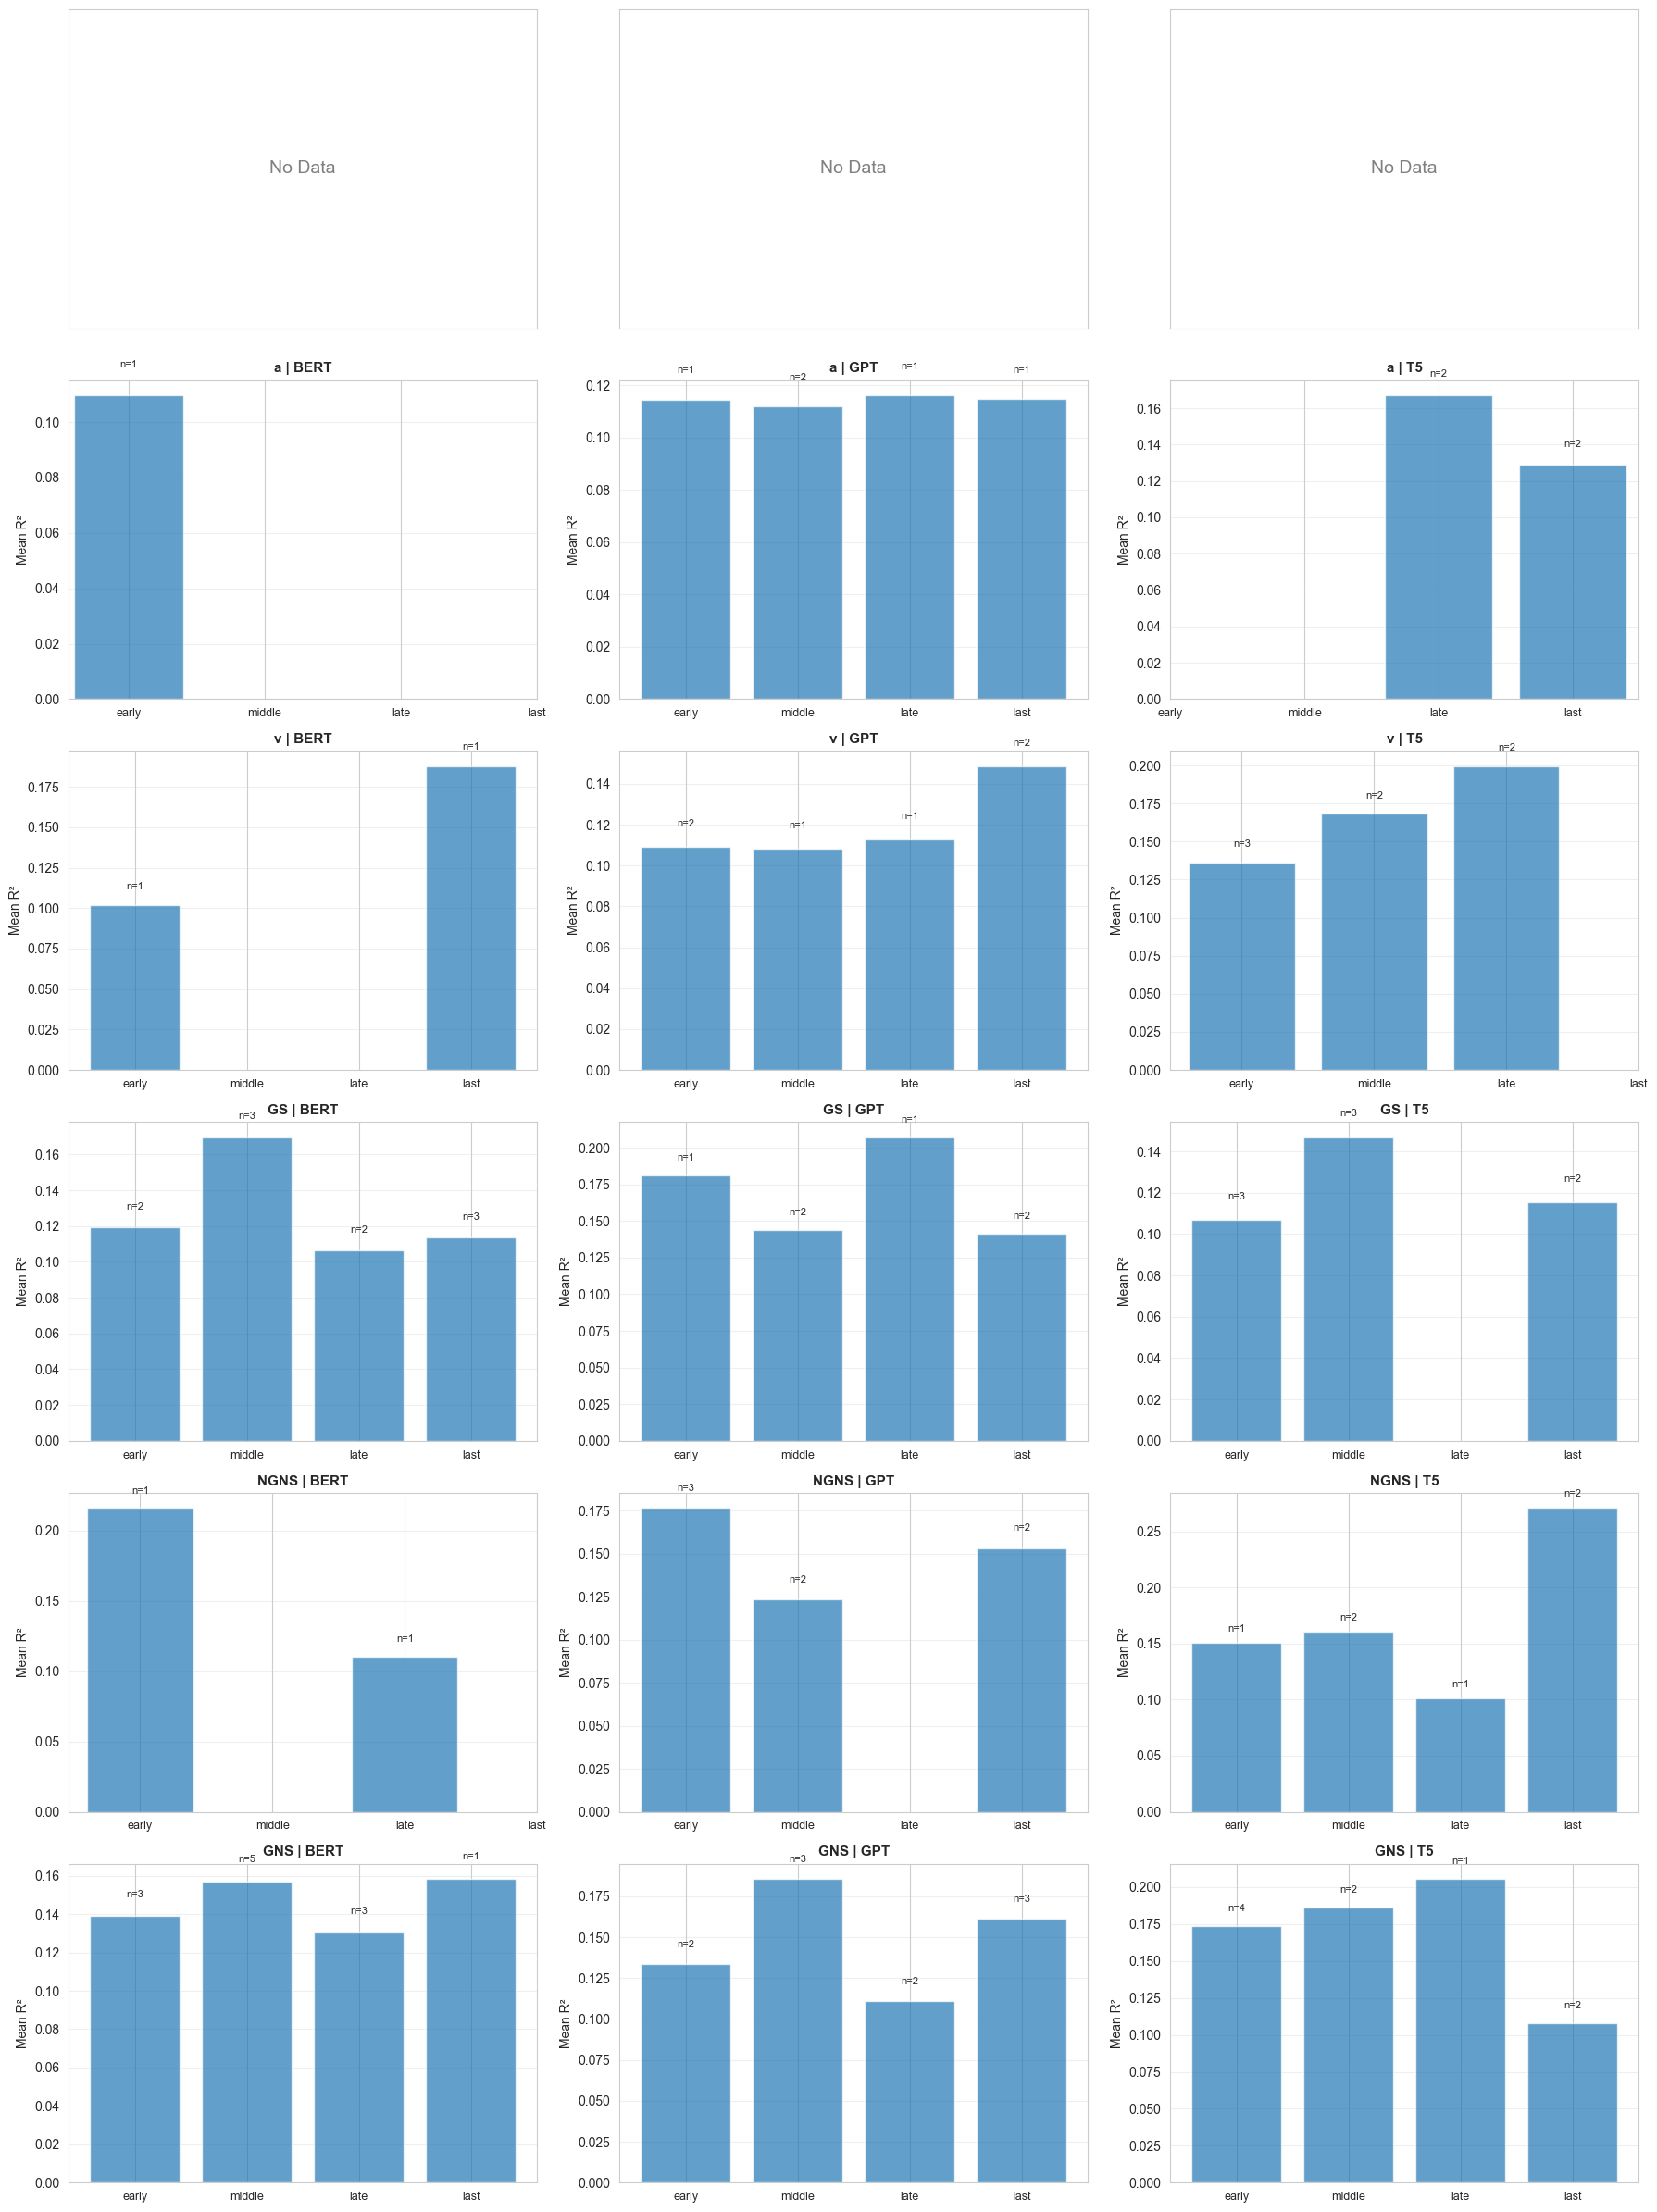


✓ Summary statistics saved to figures/enhanced_analysis/

Analysis complete!


In [ ]:
"""
Enhanced Time Window Analysis with:
1. Layer × Condition interactions
2. Participant-level vs aggregated visualizations
3. English vs non-English subject comparisons
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from helpers.constants import *

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

## Configuration
RESULTS_DIR = "results_selective_windows"
ELEC_PATH = f"{EXPANSION_PATH}/Sub-Mat-Converted/elecFinal.mat"

# Analysis parameters
SUBJECTS = [1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17]  
CONDITIONS = ["overall", "a", "v", "GS", "NGNS", "GNS"]
LAYERS = ['early', 'middle', 'late', 'last']
TIME_WINDOWS = ['full_consolidation']
MODELS = ['BERT', 'GPT', 'T5']

# Define English subjects (from helpers.constants)
# ENGLISH_SUBS typically contains subjects who saw stimuli in English
# Adjust this list based on your actual ENGLISH_SUBS constant

# Thresholds
R2_THRESHOLD = 0.1

# Create output directory
os.makedirs('figures/enhanced_analysis', exist_ok=True)

print("Configuration loaded successfully")


## Load Electrode Metadata
elec_raw = scipy.io.loadmat(ELEC_PATH, squeeze_me=True, simplify_cells=True, struct_as_record=False)
elec_frame = pd.DataFrame(elec_raw['elec_out'])

print(f"Loaded electrode data: {len(elec_frame)} electrodes")


## Helper Functions
def load_results(subject, condition, layer, time_window):
    """Load results for specific parameters"""
    path = f"{RESULTS_DIR}/{condition}/{layer}/{time_window}/S{subject}_{condition}_{layer}_{time_window}.pkl"
    
    if not os.path.exists(path):
        return None
    
    with open(path, 'rb') as f:
        return pickle.load(f)


def extract_electrode_data(results, subject_num, elec_frame):
    """Extract and merge electrode data with brain location info"""
    all_data = []
    
    for model_name in ['bert', 'gpt', 't5']:
        results_key = f'{model_name}_results'
        if results_key not in results:
            continue
            
        df = results[results_key].copy()
        df['model'] = model_name.upper()
        df['elec_idx'] = df.index
        
        all_data.append(df)
    
    if not all_data:
        return None
    
    combined = pd.concat(all_data, ignore_index=True)
    
    # Merge with electrode metadata
    subject_elecs = elec_frame[
        (elec_frame['subjectNum'] == subject_num) & 
        (elec_frame['isRejectFSL'] != 1) & 
        (elec_frame['isRejectManual'] != 1)
    ].copy()
    
    subject_elecs['Elec_index'] = (subject_elecs['elecNum'].astype(int) - 1)
    
    merged = pd.merge(
        combined,
        subject_elecs,
        left_on='elec_idx',
        right_on='Elec_index',
        how='inner'
    )
    
    return merged


## Load All Results
all_results = []

for subject in SUBJECTS:
    print(f"\nLoading Subject {subject}...")
    
    for condition in CONDITIONS:
        for layer in LAYERS:
            for time_window in TIME_WINDOWS:
                results = load_results(subject, condition, layer, time_window)
                
                if results is None:
                    continue
                
                elec_data = extract_electrode_data(results, subject, elec_frame)
                
                if elec_data is None or len(elec_data) == 0:
                    continue
                
                # Add metadata
                elec_data['subject'] = subject
                elec_data['condition'] = condition
                elec_data['layer'] = layer
                elec_data['time_window'] = time_window
                
                # Add language group
                elec_data['language_group'] = 'English' if subject in ENGLISH_SUBS else 'Non-English'
                
                all_results.append(elec_data)

# Combine all results
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
    print(f"\nTotal dataset: {len(results_df)} electrode-model-layer-condition combinations")
else:
    print("ERROR: No results loaded!")
    results_df = None


##Filter to High-Performing Electrodes
sig_results = results_df[results_df['test_R_2'] >= R2_THRESHOLD].copy()
print(f"\nHigh-performing electrodes (R² ≥ {R2_THRESHOLD}): {len(sig_results)}")

# Define categorical ordering
layer_order = ['early', 'middle', 'late', 'last']
sig_results['layer'] = pd.Categorical(sig_results['layer'], categories=layer_order, ordered=True)


##LAYER × CONDITION INTERACTION ANALYSIS

print("\n" + "="*80)
print("LAYER × CONDITION ANALYSIS")
print("="*80)

# Aggregate by layer and condition
layer_cond_summary = sig_results.groupby(['layer', 'condition', 'model'])['test_R_2'].agg([
    'mean', 'std', 'count'
]).reset_index()

# Overall Layer × Condition heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, model in enumerate(MODELS):
    ax = axes[i]
    model_data = layer_cond_summary[layer_cond_summary['model'] == model]
    
    pivot = model_data.pivot(index='layer', columns='condition', values='mean')
    pivot = pivot.reindex(index=layer_order, columns=CONDITIONS)
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax,
                cbar_kws={'label': 'Mean R²'}, vmin=R2_THRESHOLD, vmax=0.3)
    ax.set_title(f'{model}: Layer × Condition', fontsize=14, fontweight='bold')
    ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
    ax.set_ylabel('Layer', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/layer_condition_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nLayer × Condition Summary (All Models):")
overall_summary = sig_results.groupby(['layer', 'condition'])['test_R_2'].agg(['mean', 'count'])
print(overall_summary)


##  Layer progression analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1,2 and 3 Layer progression by condition per model
for i, model in enumerate(MODELS):
    ax = axes[0, i]
    model_data = sig_results[sig_results['model'] == model]
    
    for condition in CONDITIONS:
        cond_data = model_data[model_data['condition'] == condition]
        layer_means = cond_data.groupby('layer')['test_R_2'].mean().reindex(layer_order)
        
        ax.plot(range(len(layer_order)), layer_means.values, marker='o', 
                linewidth=2, label=condition, alpha=0.8)
    
    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels(layer_order)
    ax.set_ylabel('Mean Test R²', fontsize=11, fontweight='bold')
    ax.set_title(f'{model}: Layer Progression', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

# Plots 4, 5 and 6 : Condition effect at each layer per model
for i, model in enumerate(MODELS):
    ax = axes[1, i]
    model_data = sig_results[sig_results['model'] == model]
    
    sns.boxplot(data=model_data, x='layer', y='test_R_2', hue='condition', 
                ax=ax, palette='Set2')
    ax.set_xlabel('Layer', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test R²', fontsize=11, fontweight='bold')
    ax.set_title(f'{model}: Distribution by Layer & Condition', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/layer_progression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. PARTICIPANT-LEVEL ANALYSIS

print("\n" + "="*80)
print("PARTICIPANT-LEVEL ANALYSIS")
print("="*80)

# Individual subject performance
subject_summary = sig_results.groupby(['subject', 'layer', 'condition', 'model'])['test_R_2'].agg([
    'mean', 'count'
]).reset_index()

# Plot individual subjects
n_subjects = len(sig_results['subject'].unique())
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx, subject in enumerate(sorted(sig_results['subject'].unique())):
    if idx >= 15:
        break
    
    ax = axes[idx]
    sub_data = sig_results[sig_results['subject'] == subject]
    
    # Layer × Model performance
    for model in MODELS:
        model_data = sub_data[sub_data['model'] == model]
        layer_means = model_data.groupby('layer')['test_R_2'].mean().reindex(layer_order)
        
        ax.plot(range(len(layer_order)), layer_means.values, marker='o',
                linewidth=2, label=model, alpha=0.8)
    
    ax.set_xticks(range(len(layer_order)))
    ax.set_xticklabels(layer_order, fontsize=8)
    ax.set_ylabel('Mean R²', fontsize=9)
    ax.set_title(f'Subject {subject} ({"EN" if subject in ENGLISH_SUBS else "Non-EN"})',
                fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_subjects, 15):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/participant_level_layers.png', dpi=300, bbox_inches='tight')
plt.show()


## participant vs overall conditions

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Individual subject lines + aggregated mean
ax = axes[0, 0]
for subject in sig_results['subject'].unique():
    sub_data = sig_results[sig_results['subject'] == subject]
    layer_means = sub_data.groupby('layer')['test_R_2'].mean().reindex(layer_order)
    
    color = 'blue' if subject in ENGLISH_SUBS else 'gray'
    ax.plot(range(len(layer_order)), layer_means.values, marker='o',
            linewidth=1, alpha=0.3, color=color)

# Aggregated mean
agg_means = sig_results.groupby('layer')['test_R_2'].mean().reindex(layer_order)
ax.plot(range(len(layer_order)), agg_means.values, marker='s',
        linewidth=4, color='red', label='Aggregated Mean', zorder=10)

ax.set_xticks(range(len(layer_order)))
ax.set_xticklabels(layer_order)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_title('Individual Subjects vs Aggregated', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Variance across subjects by layer
ax = axes[0, 1]
layer_variance = sig_results.groupby(['subject', 'layer'])['test_R_2'].mean().reset_index()
sns.violinplot(data=layer_variance, x='layer', y='test_R_2', ax=ax, palette='Set2')
sns.swarmplot(data=layer_variance, x='layer', y='test_R_2', ax=ax, 
              color='black', alpha=0.5, size=3)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_title('Subject Variability by Layer', fontsize=14, fontweight='bold')

# Plot 3: Number of electrodes per subject by layer
ax = axes[1, 0]
elec_counts = sig_results.groupby(['subject', 'layer']).size().reset_index(name='n_electrodes')
pivot = elec_counts.pivot(index='subject', columns='layer', values='n_electrodes')
pivot = pivot.reindex(columns=layer_order)

sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Electrode Count'})
ax.set_title('Electrode Coverage: Subject × Layer', fontsize=14, fontweight='bold')
ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('Subject', fontsize=12, fontweight='bold')

# Plot 4: Consistency across conditions per subject
ax = axes[1, 1]
cond_consistency = sig_results.groupby(['subject', 'condition'])['test_R_2'].mean().reset_index()
pivot_cond = cond_consistency.pivot(index='subject', columns='condition', values='test_R_2')
pivot_cond = pivot_cond.reindex(columns=CONDITIONS)

sns.heatmap(pivot_cond, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,
            cbar_kws={'label': 'Mean R²'}, vmin=R2_THRESHOLD)
ax.set_title('Subject × Condition Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_ylabel('Subject', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/participant_vs_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()


## english vs non-english

print("\n" + "="*80)
print("ENGLISH VS NON-ENGLISH SUBJECT COMPARISON")
print("="*80)

# Summary statistics
lang_summary = sig_results.groupby('language_group')['test_R_2'].describe()
print("\nLanguage Group Summary:")
print(lang_summary)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Overall R² distribution
ax = axes[0, 0]
sns.violinplot(data=sig_results, x='language_group', y='test_R_2', ax=ax, palette='Set2')
sns.swarmplot(data=sig_results, x='language_group', y='test_R_2', ax=ax,
              color='black', alpha=0.2, size=2)
ax.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_title('English vs Non-English: Overall Performance', fontsize=14, fontweight='bold')

# Add statistical test
from scipy.stats import mannwhitneyu
eng_r2 = sig_results[sig_results['language_group'] == 'English']['test_R_2'].values
non_eng_r2 = sig_results[sig_results['language_group'] == 'Non-English']['test_R_2'].values

if len(eng_r2) > 0 and len(non_eng_r2) > 0:
    stat, p = mannwhitneyu(eng_r2, non_eng_r2)
    ax.text(0.5, 0.95, f'Mann-Whitney U: p={p:.4f}',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: By layer
ax = axes[0, 1]
lang_layer = sig_results.groupby(['language_group', 'layer'])['test_R_2'].mean().reset_index()
sns.barplot(data=lang_layer, x='layer', y='test_R_2', hue='language_group', ax=ax, palette='Set2')
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_title('Performance by Layer', fontsize=14, fontweight='bold')
ax.legend(title='Language Group')

# Plot 3: By model
ax = axes[0, 2]
lang_model = sig_results.groupby(['language_group', 'model'])['test_R_2'].mean().reset_index()
sns.barplot(data=lang_model, x='model', y='test_R_2', hue='language_group', ax=ax, palette='Set2')
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Performance by Model', fontsize=14, fontweight='bold')
ax.legend(title='Language Group')

# Plot 4: Electrode count comparison
ax = axes[1, 0]
lang_counts = sig_results.groupby(['language_group', 'layer']).size().reset_index(name='count')
sns.barplot(data=lang_counts, x='layer', y='count', hue='language_group', ax=ax, palette='Set2')
ax.set_ylabel('Number of Electrodes', fontsize=12, fontweight='bold')
ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_title('Electrode Coverage', fontsize=14, fontweight='bold')
ax.legend(title='Language Group')

# Plot 5: Condition effects
ax = axes[1, 1]
lang_cond = sig_results.groupby(['language_group', 'condition'])['test_R_2'].mean().reset_index()
pivot_lang = lang_cond.pivot(index='condition', columns='language_group', values='test_R_2')
pivot_lang = pivot_lang.reindex(index=CONDITIONS)

pivot_lang.plot(kind='bar', ax=ax, rot=45, width=0.8)
ax.set_ylabel('Mean Test R²', fontsize=12, fontweight='bold')
ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
ax.set_title('Condition Effects', fontsize=14, fontweight='bold')
ax.legend(title='Language Group')
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: Subject counts and stats
ax = axes[1, 2]
stats_text = []

# Count subjects
n_eng = len(sig_results[sig_results['language_group'] == 'English']['subject'].unique())
n_non_eng = len(sig_results[sig_results['language_group'] == 'Non-English']['subject'].unique())

stats_text.append(f"SUBJECT COUNTS:")
stats_text.append(f"  English: {n_eng} subjects")
stats_text.append(f"  Non-English: {n_non_eng} subjects")
stats_text.append(f"")
stats_text.append(f"ELECTRODE COUNTS:")
stats_text.append(f"  English: {len(eng_r2)} electrodes")
stats_text.append(f"  Non-English: {len(non_eng_r2)} electrodes")
stats_text.append(f"")
stats_text.append(f"PERFORMANCE:")
stats_text.append(f"  English Mean R²: {np.mean(eng_r2):.4f}")
stats_text.append(f"  Non-English Mean R²: {np.mean(non_eng_r2):.4f}")
stats_text.append(f"  Difference: {np.mean(eng_r2) - np.mean(non_eng_r2):.4f}")

ax.text(0.1, 0.9, '\n'.join(stats_text), transform=ax.transAxes,
        fontsize=11, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax.set_title('Summary Statistics', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/english_vs_nonenglish.png', dpi=300, bbox_inches='tight')
plt.show()


## layer vs condition vs model

fig, axes = plt.subplots(len(CONDITIONS), len(MODELS), figsize=(18, 24))

for i, condition in enumerate(CONDITIONS):
    for j, model in enumerate(MODELS):
        ax = axes[i, j]
        
        subset = sig_results[
            (sig_results['condition'] == condition) & 
            (sig_results['model'] == model)
        ]
        
        if len(subset) > 0:
            layer_means = subset.groupby('layer')['test_R_2'].mean().reindex(layer_order)
            layer_counts = subset.groupby('layer').size().reindex(layer_order)
            
            ax.bar(range(len(layer_order)), layer_means.values, alpha=0.7)
            ax.set_xticks(range(len(layer_order)))
            ax.set_xticklabels(layer_order, fontsize=9)
            ax.set_ylabel('Mean R²', fontsize=10)
            ax.set_title(f'{condition} | {model}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add counts
            for k, (mean_val, count_val) in enumerate(zip(layer_means.values, layer_counts.values)):
                if not np.isnan(mean_val):
                    ax.text(k, mean_val + 0.01, f'n={int(count_val)}',
                            ha='center', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes,
                   ha='center', va='center', fontsize=14, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
plt.savefig('figures/enhanced_analysis/three_way_interaction.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Export Summary Statistics

# Create comprehensive summary
summary_stats = {
    'overall': sig_results.groupby(['layer', 'condition', 'model'])['test_R_2'].describe(),
    'by_subject': sig_results.groupby(['subject', 'layer', 'condition', 'model'])['test_R_2'].mean(),
    'by_language': sig_results.groupby(['language_group', 'layer', 'condition', 'model'])['test_R_2'].describe(),
}

# Save to CSV
summary_stats['overall'].to_csv('figures/enhanced_analysis/layer_condition_model_summary.csv')
summary_stats['by_subject'].to_csv('figures/enhanced_analysis/subject_level_summary.csv')
summary_stats['by_language'].to_csv('figures/enhanced_analysis/language_group_summary.csv')

print("\n✓ Summary statistics saved to figures/enhanced_analysis/")
print("\nAnalysis complete!")


OVERFITTING ANALYSIS
Saved: figures/time_window_viz/overfitting_analysis.png


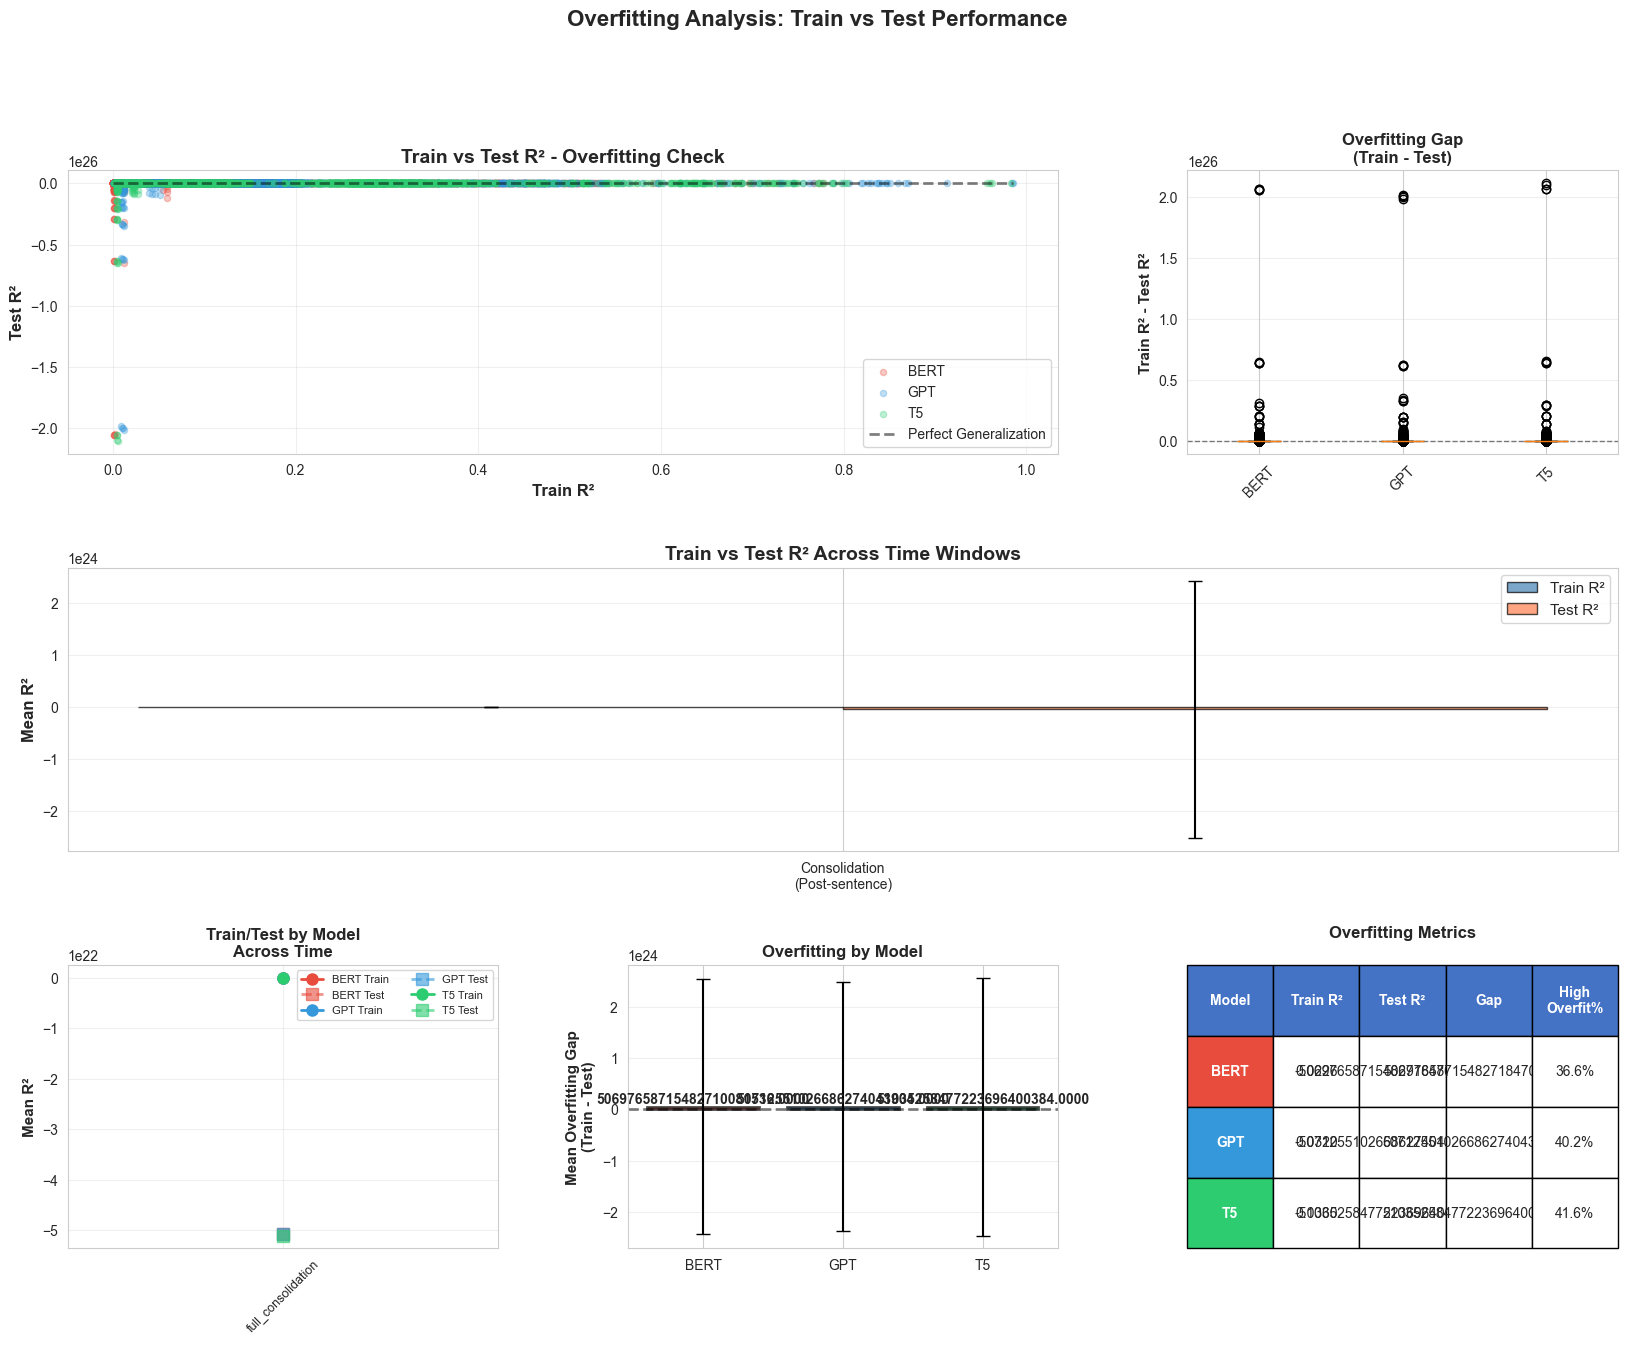


Overfitting Summary:
--------------------------------------------------------------------------------

BERT:
  Mean Train R²: 0.0226
  Mean Test R²:  -50697658715482718470144.0000
  Gap (Train-Test): 50697658715482718470144.0000
  ⚠️  WARNING: Significant overfitting detected!

GPT:
  Mean Train R²: 0.0320
  Mean Test R²:  -50712551026686274043904.0000
  Gap (Train-Test): 50712551026686274043904.0000
  ⚠️  WARNING: Significant overfitting detected!

T5:
  Mean Train R²: 0.0360
  Mean Test R²:  -51035258477223696400384.0000
  Gap (Train-Test): 51035258477223696400384.0000
  ⚠️  WARNING: Significant overfitting detected!


In [ ]:
from matplotlib import gridspec 


TIME_WINDOW_LABELS = {
    'W2': 'Word 2',
    'W3': 'Word 3',
    'W4': 'Word 4\n(Final)',
    'full_consolidation': 'Consolidation\n(Post-sentence)'
}


R2_THRESHOLD = 0.1  # Minimum R² to consider significant
TOP_N_REGIONS = 15  # Number of top regions to display


TIME_WINDOW_COLORS = {
    'W2': '#f39c12',
    'W3': '#f1c40f',
    'W4': '#2ecc71',
    'full_consolidation': '#3498db'
}

MODEL_COLORS = {
    'BERT': '#e74c3c',
    'GPT': '#3498db',
    'T5': '#2ecc71'
}

def plot_overfitting_analysis(df, save_path=None):
    """
    Compare train vs test R² across models and time windows to detect overfitting
    Overfitting indicators:
    - Train R² >> Test R² (large gap)
    - Train R² high but test R² low
    """
    if isinstance(df, list):
        df = pd.concat(df, ignore_index=True)
    
    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
    
    # Filter for valid train R² values
    df_valid = df[(df['train_R_2'].notna()) & (df['train_R_2'] > -1)].copy()
    
    # Calculate overfitting gap once at the start
    df_valid['overfitting_gap'] = df_valid['train_R_2'] - df_valid['test_R_2']
    
    # 1. Scatter plot: Train vs Test R² by model
    ax1 = fig.add_subplot(gs[0, :2])
    for model, color in MODEL_COLORS.items():
        model_data = df_valid[df_valid['model'] == model]
        ax1.scatter(model_data['train_R_2'], model_data['test_R_2'], 
                   alpha=0.3, s=20, c=color, label=model)
    
    # Add diagonal line (perfect generalization)
    max_r2 = max(df_valid['train_R_2'].max(), df_valid['test_R_2'].max())
    ax1.plot([0, max_r2], [0, max_r2], 'k--', linewidth=2, alpha=0.5, label='Perfect Generalization')
    
    ax1.set_xlabel('Train R²', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
    ax1.set_title('Train vs Test R² - Overfitting Check', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Overfitting gap distribution by model
    ax2 = fig.add_subplot(gs[0, 2])
    
    model_gaps = [df_valid[df_valid['model'] == model]['overfitting_gap'].values 
                  for model in MODELS]
    bp = ax2.boxplot(model_gaps, labels=MODELS, patch_artist=True)
    
    for patch, model in zip(bp['boxes'], MODELS):
        patch.set_facecolor(MODEL_COLORS[model])
        patch.set_alpha(0.7)
    
    ax2.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_ylabel('Train R² - Test R²', fontsize=11, fontweight='bold')
    ax2.set_title('Overfitting Gap\n(Train - Test)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    # 3. Train vs Test by time window
    ax3 = fig.add_subplot(gs[1, :])
    
    time_stats = df_valid.groupby('time_window').agg({
        'train_R_2': ['mean', 'std'],
        'test_R_2': ['mean', 'std']
    }).reindex(TIME_WINDOWS)
    
    x = np.arange(len(TIME_WINDOWS))
    width = 0.35
    
    ax3.bar(x - width/2, time_stats[('train_R_2', 'mean')], width,
           yerr=time_stats[('train_R_2', 'std')], label='Train R²',
           color='steelblue', alpha=0.7, capsize=5, edgecolor='black')
    ax3.bar(x + width/2, time_stats[('test_R_2', 'mean')], width,
           yerr=time_stats[('test_R_2', 'std')], label='Test R²',
           color='coral', alpha=0.7, capsize=5, edgecolor='black')
    
    ax3.set_xticks(x)
    ax3.set_xticklabels([TIME_WINDOW_LABELS[tw] for tw in TIME_WINDOWS], fontsize=10)
    ax3.set_ylabel('Mean R²', fontsize=12, fontweight='bold')
    ax3.set_title('Train vs Test R² Across Time Windows', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Train vs Test by model across time windows
    ax4 = fig.add_subplot(gs[2, 0])
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]
        time_train = model_data.groupby('time_window')['train_R_2'].mean().reindex(TIME_WINDOWS)
        time_test = model_data.groupby('time_window')['test_R_2'].mean().reindex(TIME_WINDOWS)
        
        x = np.arange(len(TIME_WINDOWS))
        ax4.plot(x, time_train, 'o-', label=f'{model} Train', 
                color=MODEL_COLORS[model], linewidth=2, markersize=8)
        ax4.plot(x, time_test, 's--', label=f'{model} Test', 
                color=MODEL_COLORS[model], linewidth=2, markersize=8, alpha=0.6)
    
    ax4.set_xticks(x)
    ax4.set_xticklabels([tw for tw in TIME_WINDOWS], fontsize=9, rotation=45)
    ax4.set_ylabel('Mean R²', fontsize=11, fontweight='bold')
    ax4.set_title('Train/Test by Model\nAcross Time', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=8, ncol=2)
    ax4.grid(True, alpha=0.3)
    
    # 5. Model comparison: Average overfitting gap
    ax5 = fig.add_subplot(gs[2, 1])
    model_stats = df_valid.groupby('model').agg({
        'overfitting_gap': ['mean', 'std', 'count']
    })
    
    colors = [MODEL_COLORS[m] for m in MODELS]
    bars = ax5.bar(MODELS, model_stats[('overfitting_gap', 'mean')],
                   yerr=model_stats[('overfitting_gap', 'std')],
                   color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=2)
    
    ax5.axhline(y=0, color='k', linestyle='--', linewidth=2, alpha=0.5)
    ax5.set_ylabel('Mean Overfitting Gap\n(Train - Test)', fontsize=11, fontweight='bold')
    ax5.set_title('Overfitting by Model', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom' if height > 0 else 'top',
                fontweight='bold', fontsize=10)
    
    # 6. Overfitting metrics table
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('tight')
    ax6.axis('off')
    
    # Calculate overfitting metrics - USE df_valid instead of results_df
    metrics_data = []
    for model in MODELS:
        model_data = df_valid[df_valid['model'] == model]
        mean_train = model_data['train_R_2'].mean()
        mean_test = model_data['test_R_2'].mean()
        mean_gap = model_data['overfitting_gap'].mean()
        
        # Percentage of high-overfitting cases (gap > 0.05)
        high_overfit_pct = (model_data['overfitting_gap'] > 0.05).mean() * 100
        
        metrics_data.append([
            model,
            f'{mean_train:.4f}',
            f'{mean_test:.4f}',
            f'{mean_gap:.4f}',
            f'{high_overfit_pct:.1f}%'
        ])
    
    table = ax6.table(cellText=metrics_data,
                     colLabels=['Model', 'Train R²', 'Test R²', 'Gap', 'High\nOverfit%'],
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code the header
    for i in range(5):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Color code model rows
    for i, model in enumerate(MODELS):
        table[(i+1, 0)].set_facecolor(MODEL_COLORS[model])
        table[(i+1, 0)].set_text_props(weight='bold', color='white')
    
    ax6.set_title('Overfitting Metrics', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle('Overfitting Analysis: Train vs Test Performance', 
                fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.tight_layout()
    
    # Return both the figure and df_valid 
    return fig, df_valid


# Generate overfitting analysis
print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)

fig, df_valid = plot_overfitting_analysis(all_results, 'figures/time_window_viz/overfitting_analysis.png')
plt.show()

# Print summary statistics
print("\nOverfitting Summary:")
print("-" * 80)

for model in MODELS:
    model_data = df_valid[df_valid['model'] == model]

    if len(model_data) > 0:
        mean_train = model_data['train_R_2'].mean()
        mean_test = model_data['test_R_2'].mean()
        gap = mean_train - mean_test
        
        print(f"\n{model}:")
        print(f"  Mean Train R²: {mean_train:.4f}")
        print(f"  Mean Test R²:  {mean_test:.4f}")
        print(f"  Gap (Train-Test): {gap:.4f}")
        
        if gap > 0.05:
            print(f"  ⚠️  WARNING: Significant overfitting detected!")
        elif gap > 0.02:
            print(f"  ⚡ Mild overfitting")
        else:
            print(f"  ✓ Good generalization")

# Best predicted brain region

In [ ]:


def plot_top_brain_regions_analysis(results_df, MODEL_COLORS, condition_colors, TIME_WINDOW_COLORS, 
                                     TIME_WINDOW_LABELS, top_n=5, save_path=None):
    """
    Analyze and plot top brain regions with strict performance criteria.
    
    Filters for electrodes with:
    1) ≤15% difference between test and train R²
    2) Significant (p < 0.05)
    3) Highest Pearson R values
    
    Parameters:
    -----------
    results_df : DataFrame
        Must contain: test_R_2, train_R_2, p_value, test_R, model, condition, 
                      time_window, parcLabel, electrode
    MODEL_COLORS : dict
        Colors for each model
    condition_colors : dict
        Colors for each condition
    TIME_WINDOW_COLORS : dict
        Colors for each time window
    TIME_WINDOW_LABELS : dict
        Labels for time windows
    top_n : int
        Number of top regions to display (default 5)
    save_path : str
        Path to save figure
    """
    
    # Step 1: Filter electrodes by criteria
    print("="*80)
    print("FILTERING ELECTRODES BY QUALITY CRITERIA")
    print("="*80)
    
    # Calculate train-test gap percentage
    results_df['gap_percentage'] = ((results_df['train_R_2'] - results_df['test_R_2']) / 
                                     results_df['train_R_2']) * 100
    
    # Apply filters
    filtered_df = results_df[
        (results_df['gap_percentage'] <= 15) &  # ≤15% gap
        (results_df['p_value'] < 0.05) &         # Significant
        (results_df['test_R_2'] > 0.1)           # High-performing
    ].copy()
    
    print(f"\nOriginal dataset: {len(results_df)} electrode-model combinations")
    print(f"After filtering: {len(filtered_df)} combinations")
    print(f"  - ≤15% train-test gap: {(results_df['gap_percentage'] <= 15).sum()}")
    print(f"  - Significant (p<0.05): {(results_df['p_value'] < 0.05).sum()}")
    print(f"  - Meet all criteria: {len(filtered_df)}")
    
    # Step 2: Get top regions by average Pearson R
    region_stats = filtered_df.groupby('parcLabel').agg({
        'test_R': 'mean',
        'test_R_2': 'mean',
        'gap_percentage': 'mean',
        'electrode': 'nunique',
        'model': lambda x: list(x.unique()),
        'condition': lambda x: list(x.unique()),
        'time_window': lambda x: list(x.unique())
    }).reset_index()
    
    region_stats.columns = ['parcLabel', 'mean_test_R', 'mean_test_R2', 'mean_gap_pct', 
                            'n_electrodes', 'models', 'conditions', 'time_windows']
    
    # Sort by Pearson R and get top N
    top_regions = region_stats.nlargest(top_n, 'mean_test_R')
    
    print(f"\nTop {top_n} Brain Regions by Mean Pearson R:")
    print("-"*80)
    for idx, row in top_regions.iterrows():
        print(f"\n{row['parcLabel']}:")
        print(f"  Mean Pearson R: {row['mean_test_R']:.3f}")
        print(f"  Mean R²: {row['mean_test_R2']:.3f}")
        print(f"  Mean gap: {row['mean_gap_pct']:.1f}%")
        print(f"  N electrodes: {row['n_electrodes']}")
        print(f"  Models: {', '.join(row['models'])}")
        print(f"  Conditions: {', '.join(row['conditions'])}")
        print(f"  Time windows: {', '.join(row['time_windows'])}")
    
    # Filter data to only top regions
    top_region_data = filtered_df[filtered_df['parcLabel'].isin(top_regions['parcLabel'])]
    
    # Create figure with 3x2 grid
    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    fig.suptitle(f'Top {top_n} Brain Regions: High-Quality Prediction Analysis\n'
                 f'(≤15% train-test gap, p<0.05, sorted by Pearson R)', 
                 fontsize=22, fontweight='bold', y=0.995)
    

    ax = fig.add_subplot(gs[0, 0])
    
    for region in top_regions['parcLabel']:
        region_subset = top_region_data[top_region_data['parcLabel'] == region]
        ax.scatter(region_subset['train_R_2'], region_subset['test_R_2'],
                  s=100, alpha=0.6, label=region[:25], edgecolors='black', linewidths=0.5)
    
    # Add identity line
    max_val = max(top_region_data['train_R_2'].max(), top_region_data['test_R_2'].max())
    min_val = min(top_region_data['train_R_2'].min(), top_region_data['test_R_2'].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.5, label='Perfect')
    
    # Add 15% boundary
    train_range = np.linspace(min_val, max_val, 100)
    lower_bound = 0.85 * train_range
    ax.plot(train_range, lower_bound, 'g--', linewidth=2, alpha=0.7, label='15% threshold')
    
    ax.set_xlabel('Train R²', fontsize=15, fontweight='bold')
    ax.set_ylabel('Test R²', fontsize=15, fontweight='bold')
    ax.set_title('A) Train vs Test R² for Top Regions', fontsize=17, fontweight='bold', pad=15)
    ax.legend(frameon=True, shadow=True, fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    

    ax = fig.add_subplot(gs[0, 1])
    
    gap_data = [top_region_data[top_region_data['parcLabel'] == region]['gap_percentage'].values
                for region in top_regions['parcLabel']]
    
    bp = ax.boxplot(gap_data, labels=[r[:15] for r in top_regions['parcLabel']],
                    patch_artist=True, showfliers=True, widths=0.6)
    
    # Color boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(gap_data)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['medians', 'whiskers', 'caps']:
        plt.setp(bp[element], linewidth=2)
    
    ax.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.7, label='15% threshold')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.set_ylabel('Train - Test Gap (%)', fontsize=15, fontweight='bold')
    ax.set_xlabel('Brain Region', fontsize=15, fontweight='bold')
    ax.set_title('B) Overfitting Control (All ≤15%)', fontsize=17, fontweight='bold', pad=15)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    

    ax = fig.add_subplot(gs[1, 0])
    
    x = np.arange(len(top_regions))
    width = 0.35
    
    ax.bar(x - width/2, top_regions['mean_test_R2'], width, label='Mean R²',
           color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.bar(x + width/2, top_regions['mean_test_R'], width, label='Mean Pearson R',
           color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for i, (r2, r) in enumerate(zip(top_regions['mean_test_R2'], top_regions['mean_test_R'])):
        ax.text(i - width/2, r2 + 0.01, f'{r2:.3f}', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
        ax.text(i + width/2, r + 0.01, f'{r:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)
    
    ax.set_xlabel('Brain Region', fontsize=15, fontweight='bold')
    ax.set_ylabel('Performance Metric', fontsize=15, fontweight='bold')
    ax.set_title('C) R² vs Pearson R Comparison', fontsize=17, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([r[:15] for r in top_regions['parcLabel']], 
                       rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=13, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    ax = fig.add_subplot(gs[1, 1])
    
    model_counts = top_region_data.groupby(['parcLabel', 'model']).size().unstack(fill_value=0)
    model_counts = model_counts.reindex(top_regions['parcLabel'])
    
    x = np.arange(len(model_counts))
    width = 0.25
    
    for i, model in enumerate(['BERT', 'GPT', 'T5']):
        if model in model_counts.columns:
            offset = (i - 1) * width
            ax.bar(x + offset, model_counts[model], width, label=model,
                   color=MODEL_COLORS.get(model, '#95a5a6'), 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Brain Region', fontsize=15, fontweight='bold')
    ax.set_ylabel('Number of Significant Electrodes', fontsize=15, fontweight='bold')
    ax.set_title('D) Model Distribution by Region', fontsize=17, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([r[:15] for r in model_counts.index], 
                       rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=13, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    ax = fig.add_subplot(gs[2, 0])
    
    condition_counts = top_region_data.groupby(['parcLabel', 'condition']).size().unstack(fill_value=0)
    condition_counts = condition_counts.reindex(top_regions['parcLabel'])
    condition_order = ['NGNS', 'GNS', 'GS']
    condition_counts = condition_counts.reindex(columns=condition_order, fill_value=0)
    
    x = np.arange(len(condition_counts))
    width = 0.25
    
    for i, condition in enumerate(condition_order):
        if condition in condition_counts.columns:
            offset = (i - 1) * width
            ax.bar(x + offset, condition_counts[condition], width, label=condition,
                   color=condition_colors.get(condition, '#95a5a6'),
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Brain Region', fontsize=15, fontweight='bold')
    ax.set_ylabel('Number of Significant Electrodes', fontsize=15, fontweight='bold')
    ax.set_title('E) Grammar Condition Distribution by Region', fontsize=17, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([r[:15] for r in condition_counts.index],
                       rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=13, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

    ax = fig.add_subplot(gs[2, 1])
    
    tw_counts = top_region_data.groupby(['parcLabel', 'time_window']).size().unstack(fill_value=0)
    tw_counts = tw_counts.reindex(top_regions['parcLabel'])
    tw_order = ['W2', 'W3', 'W4', 'full_consolidation']
    tw_counts = tw_counts.reindex(columns=tw_order, fill_value=0)
    
    x = np.arange(len(tw_counts))
    width = 0.2
    
    for i, tw in enumerate(tw_order):
        if tw in tw_counts.columns:
            offset = (i - 1.5) * width
            label = TIME_WINDOW_LABELS.get(tw, tw)
            ax.bar(x + offset, tw_counts[tw], width, label=label,
                   color=TIME_WINDOW_COLORS.get(tw, '#95a5a6'),
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Brain Region', fontsize=15, fontweight='bold')
    ax.set_ylabel('Number of Significant Electrodes', fontsize=15, fontweight='bold')
    ax.set_title('F) Time Window Distribution by Region', fontsize=17, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([r[:15] for r in tw_counts.index],
                       rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=11, frameon=True, shadow=True, ncol=2)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Saved: {save_path}")
    
    plt.show()
    
    # Return summary dataframe
    return top_regions, top_region_data

print("✓ Top brain regions analysis function defined")

✓ Top brain regions analysis function defined


In [2]:
top_regions_df, top_region_data = plot_top_brain_regions_analysis(
    results_df=results_df,
    MODEL_COLORS=MODEL_COLORS,
    condition_colors=condition_colors,
    TIME_WINDOW_COLORS=TIME_WINDOW_COLORS,
    TIME_WINDOW_LABELS=TIME_WINDOW_LABELS,
    top_n=5,
    save_path='figures/top_brain_regions_analysis.png'
)

NameError: name 'results_df' is not defined